
# ESPAC LCIA Poster Storyboard

This notebook parses and presents all sheets from `outputs/ESPAC LCIA.xlsx` with poster-ready visuals and strict traceability to ESPAC summary references (`n` datapoints).


In [1]:

from __future__ import annotations

from pathlib import Path
import re
import textwrap
import math
import unicodedata
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from IPython.display import display, Markdown


# ---------- Paths ----------
ROOT = Path.cwd()
if not (ROOT / "outputs" / "ESPAC LCIA.xlsx").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from scripts.crop_groups import infer_crop_group_row
import textwrap

WB_PATH = ROOT / "outputs" / "ESPAC LCIA.xlsx"
OUT_REPORTS = ROOT / "outputs" / "reports"
OUT_FIGS = OUT_REPORTS / "figures_lcia_poster"
OUT_REPORTS.mkdir(parents=True, exist_ok=True)
OUT_FIGS.mkdir(parents=True, exist_ok=True)

SUMMARY_FILES = {
    "crop_national": ROOT / "outputs" / "CSVs" / "03-05_espac_crop_lci_table_filtered_dfe__summary_crop_national.csv",
    "crop_group_national": ROOT / "outputs" / "CSVs" / "03-05_espac_crop_lci_table_filtered_dfe__summary_crop_group_national.csv",
    "region": ROOT / "outputs" / "CSVs" / "03-05_espac_crop_lci_table_filtered_dfe__summary_region.csv",
    "livestock_product": ROOT / "outputs" / "CSVs" / "03-05_espac_livestock_lci_table_filtered_dfe__summary_product.csv",
}

# ---------- Visual Theme ----------
PALETTE = {
    "bg": "#f7f4ea",
    "ink": "#1f2a44",
    "accent": "#d96f32",
    "accent2": "#2a9d8f",
    "grid": "#d8d2c2",
    "hot": "#c44e52",
    "cool": "#4c78a8",
}

plt.rcParams.update({
    "figure.facecolor": "none",
    "axes.facecolor": "none",
    "axes.edgecolor": PALETTE["ink"],
    "axes.labelcolor": PALETTE["ink"],
    "xtick.color": PALETTE["ink"],
    "ytick.color": PALETTE["ink"],
    "text.color": PALETTE["ink"],
    "axes.titleweight": "bold",
    "font.size": 10,
    "figure.dpi": 130,
    "savefig.dpi": 320,
    "savefig.facecolor": "none",
    "savefig.edgecolor": "none",
    "axes.grid": True,
    "grid.color": PALETTE["grid"],
    "grid.alpha": 0.45,
    "grid.linestyle": ":",
})


def normalize_text(s: object) -> str:
    t = unicodedata.normalize("NFKD", str(s if s is not None else ""))
    t = "".join(ch for ch in t if not unicodedata.combining(ch))
    t = re.sub(r"\s+", " ", t).strip().lower()
    return t


def slugify(s: object) -> str:
    t = normalize_text(s)
    t = re.sub(r"[^a-z0-9]+", "_", t)
    t = re.sub(r"_+", "_", t).strip("_")
    return t or "x"


def clean_header_value(v: object) -> str:
    if pd.isna(v):
        return ""
    t = str(v).strip()
    if not t or t.lower().startswith("unnamed"):
        return ""
    return t



def classify_metric_domain(metric: object) -> str:
    m = normalize_text(metric)
    m_space = m.replace("_", " ")
    crop_tokens = [
        "crop_", "cereals", "fruits", "roots_tubers", "pulses_oilseeds", "vegetables", "forages_pastures", "industrial_cash"
    ]
    livestock_tokens = [
        "product_", "milk", "eggs", "cattle", "swine", "ovine", "goat", "meat_poultry", "horse", "mule", "donkey"
    ]
    if any(t in m for t in crop_tokens):
        return "crops"
    if any(t in m for t in livestock_tokens):
        return "livestock"
    return "other"



def summarize_strategy_concept(metric: object) -> str:
    m = normalize_text(metric)
    m_space = m.replace("_", " ")
    if "province" in m:
        if "crop_" in m:
            return "crop, province"
        return "inventory, province"
    if "region" in m:
        if "crop_" in m:
            return "crop, region"
        return "inventory, region"
    if any(g in m for g in ["cereals", "forages_pastures", "fruits", "industrial_cash", "pulses_oilseeds", "roots_tubers", "vegetables"]) or any(g in m_space for g in ["cereals", "forages pastures", "fruits", "industrial cash", "pulses oilseeds", "roots tubers", "vegetables"]):
        return "crop group, national"
    if "group" in m:
        return "crop group, national"
    if "crop_" in m:
        return "crop, national"
    if "product_" in m:
        return "livestock product, national"
    if "milk" in m or "eggs" in m or "cattle" in m or "swine" in m or "ovine" in m or "goat" in m or "poultry" in m:
        return "livestock product, national"
    return "inventory, national"


def extract_entity_name(metric: object) -> str:
    raw = str(metric or "").strip()
    m = normalize_text(raw)

    # Crop names
    m_crop = re.search(r"crop_([a-z0-9_]+?)_category", m)
    if m_crop:
        base = m_crop.group(1).replace("_", " ").strip()
        # Preserve regional/provincial distinction so labels do not collapse.
        m_prov = re.search(r"province_([a-z0-9_]+)", m)
        if m_prov:
            loc_raw = re.sub(r"_summary_strategy_\d+", "", m_prov.group(1)).strip("_")
            loc = loc_raw.replace("_", " ").strip()
            return f"{base} - {loc}"
        m_reg = re.search(r"region_([a-z0-9_]+)", m)
        if m_reg:
            loc_raw = re.sub(r"_summary_strategy_\d+", "", m_reg.group(1)).strip("_")
            loc = loc_raw.replace("_", " ").strip()
            return f"{base} - {loc}"
        return base

    # Crop groups
    m_group = re.search(r"(cereals|forages_pastures|fruits|industrial_cash|pulses_oilseeds|roots_tubers|vegetables)", m)
    if m_group:
        return m_group.group(1).replace("_", " ")

    # Livestock products
    m_prod = re.search(r"product_([a-z0-9_]+?)_summary", m)
    if m_prod:
        return m_prod.group(1).replace("_", " ").strip()

    if "milk" in m:
        return "milk"
    if "eggs" in m:
        return "eggs"
    if "cattle" in m:
        return "cattle"

    return slugify(raw).replace("_", " ")[:36]


def compact_metric_label(metric: object) -> str:
    ent = extract_entity_name(metric)
    concept = summarize_strategy_concept(metric)
    label = f"{ent} | {concept}"
    label = re.sub(r"\bsummary strategy\s*\d+\b", "", label, flags=re.IGNORECASE)
    label = re.sub(r"\s{2,}", " ", label).replace(" - |", " |").strip()
    return label


In [2]:

# ---------- Workbook Parsing ----------

def detect_header_row(raw: pd.DataFrame, max_scan: int = 15) -> int:
    best_row = 0
    best_score = -1
    scan_n = min(max_scan, len(raw))
    for i in range(scan_n):
        row = raw.iloc[i]
        non_null = row.notna().sum()
        texty = sum(bool(clean_header_value(v)) for v in row)
        score = int(non_null + texty * 2)
        if score > best_score:
            best_score = score
            best_row = i
    return best_row


def reconstruct_headers(raw: pd.DataFrame, header_row: int, depth: int = 3) -> list[str]:
    cols = []
    ncols = raw.shape[1]

    def infer_fallback_label(col_idx: int) -> str:
        # Infer semantic header from first non-empty body cell when merged headers are blank.
        body_start = min(header_row + depth, len(raw) - 1)
        token = ""
        for rr in range(body_start, len(raw)):
            v = raw.iat[rr, col_idx]
            if pd.isna(v):
                continue
            t = str(v).strip()
            if not t:
                continue
            tl = normalize_text(t)
            if tl in {"nan", "none"}:
                continue
            token = t
            break

        if not token:
            return f"field_{col_idx+1:03d}"

        tnorm = normalize_text(token)
        if "kg crop" in tnorm or tnorm.startswith("1 kg crop"):
            return "inventory_label"
        if "damage" in tnorm or "dano" in tnorm:
            return "impact_category"
        if "unit" in tnorm or tnorm in {"pt", "kg", "m3", "mj"}:
            return "unit"
        if "calculation" in tnorm or "results" in tnorm or "comparar" in tnorm:
            return f"meta_{col_idx+1:03d}"

        token_slug = slugify(token)
        return token_slug if token_slug else f"field_{col_idx+1:03d}"

    for c in range(ncols):
        parts = []
        for r in range(header_row, min(header_row + depth, len(raw))):
            token = clean_header_value(raw.iat[r, c])
            if token:
                parts.append(token)
        if parts:
            label = " | ".join(dict.fromkeys(parts))
            cols.append(slugify(label))
        else:
            cols.append(infer_fallback_label(c))

    # deduplicate
    seen = {}
    unique = []
    for c in cols:
        k = seen.get(c, 0)
        seen[c] = k + 1
        unique.append(c if k == 0 else f"{c}_{k+1}")
    return unique


def rename_placeholder_columns(df: pd.DataFrame) -> pd.DataFrame:
    ren = {}
    ind_idx = 1
    meta_idx = 1
    for c in list(df.columns):
        if not re.fullmatch(r"col_\d+", str(c)):
            continue

        s = df[c]
        s_text = s.dropna().astype(str).str.strip()
        sample = " ".join(s_text.head(30).tolist())
        sample_norm = normalize_text(sample)
        numeric_share = pd.to_numeric(s, errors="coerce").notna().mean() if len(s) else 0

        if "kg crop" in sample_norm or "category:" in sample_norm:
            new = "inventory_label"
        elif "dano" in sample_norm or "damage" in sample_norm or "impact" in sample_norm:
            new = "impact_category"
        elif re.search(r"\b(pt|kg|m3|mj)\b", sample_norm) or "unidad" in sample_norm or "unit" in sample_norm:
            new = "unit"
        elif numeric_share >= 0.35:
            new = f"indicator_{ind_idx:03d}"
            ind_idx += 1
        else:
            new = f"meta_{meta_idx:03d}"
            meta_idx += 1

        ren[c] = new

    if not ren:
        return df

    df = df.rename(columns=ren)
    # Keep names unique after replacements
    seen = {}
    new_cols = []
    for c in df.columns:
        k = seen.get(c, 0)
        seen[c] = k + 1
        new_cols.append(c if k == 0 else f"{c}_{k+1}")
    df.columns = new_cols
    return df


def parse_sheet(xls: pd.ExcelFile, sheet_name: str) -> tuple[pd.DataFrame, dict]:
    raw = xls.parse(sheet_name=sheet_name, header=None)
    hdr = detect_header_row(raw)
    cols = reconstruct_headers(raw, hdr, depth=3)
    body = raw.iloc[hdr + 1 :].copy()
    body.columns = cols
    body = body.dropna(axis=0, how="all").dropna(axis=1, how="all")
    body = rename_placeholder_columns(body)
    body = body.reset_index(drop=True)

    meta = {
        "sheet_name": sheet_name,
        "header_row_detected": int(hdr),
        "rows_raw": int(raw.shape[0]),
        "cols_raw": int(raw.shape[1]),
        "rows_clean": int(body.shape[0]),
        "cols_clean": int(body.shape[1]),
        "non_null_cells": int(body.notna().sum().sum()),
    }
    return body, meta

xls = pd.ExcelFile(WB_PATH)
parsed = {}
audit_rows = []
for s in xls.sheet_names:
    df_s, meta_s = parse_sheet(xls, s)
    parsed[s] = df_s
    audit_rows.append(meta_s)

audit_df = pd.DataFrame(audit_rows)
display(Markdown("## Workbook Audit"))
display(audit_df)

audit_df.to_csv(OUT_REPORTS / "7_lcia_workbook_audit.csv", index=False)
for s, d in parsed.items():
    d.to_csv(OUT_REPORTS / f"7_lcia_cleaned_{slugify(s)}.csv", index=False)


## Workbook Audit

,sheet_name,header_row_detected,rows_raw,cols_raw,rows_clean,cols_clean,non_null_cells
0,ESPAC,1,32,23,29,22,164
1,regional differences,3,28,27,23,22,164
2,comparisons,1,20,24,18,14,132
3,individual tropical crops,10,93,146,81,146,892
4,uncertainty,2,144,31,129,31,1756
5,diets,10,49,20,37,19,249


In [3]:

# ---------- Load Summary Reference Tables ----------
summary_tables = {k: pd.read_csv(v) for k, v in SUMMARY_FILES.items()}

for name, df in summary_tables.items():
    crop_series = df["Crop"] if "Crop" in df.columns else pd.Series(["" for _ in range(len(df))])
    df["crop_norm"] = crop_series.map(normalize_text)
    if "Crop_group" in df.columns:
        df["crop_group_norm"] = df["Crop_group"].map(normalize_text)
    if "Region" in df.columns:
        df["region_norm"] = df["Region"].map(normalize_text)

summary_ref_rows = []
for name, df in summary_tables.items():
    summary_ref_rows.append({
        "source_summary_file": str(SUMMARY_FILES[name].relative_to(ROOT)),
        "source_inventory_level": name,
        "rows": len(df),
        "count_non_null": int(df["count"].notna().sum()) if "count" in df.columns else 0,
    })

summary_ref_df = pd.DataFrame(summary_ref_rows)
display(Markdown("## Summary Reference Tables"))
display(summary_ref_df)
summary_ref_df.to_csv(OUT_REPORTS / "7_lcia_summary_reference_inventory.csv", index=False)


## Summary Reference Tables

,source_summary_file,source_inventory_level,rows,count_non_null
0,outputs\CSVs\03-05_espac_crop_lci_table_filter...,crop_national,55,55
1,outputs\CSVs\03-05_espac_crop_lci_table_filter...,crop_group_national,7,7
2,outputs\CSVs\03-05_espac_crop_lci_table_filter...,region,3,3
3,outputs\CSVs\03-05_espac_livestock_lci_table_f...,livestock_product,10,0



## Sheet: ESPAC
How to read: baseline aggregate impact profile; normalized fingerprint highlights relative hotspot intensity while side labels retain absolute magnitude and traceability tags.


,metric,value,domain,norm_0_1,source_summary_file,source_inventory_level,n,source_key,metric_short
0,industrial_cash_summary_strategy_8,4.044619,crops,1.000000,outputs\CSVs\03-05_espac_crop_lci_table_filter...,crop_group_national,42270,crops aggregate proxy,"industrial cash | crop group, national"
1,pulses_oilseeds_summary_strategy_8,2.296082,crops,0.558278,outputs\CSVs\03-05_espac_crop_lci_table_filter...,crop_group_national,42270,crops aggregate proxy,"pulses oilseeds | crop group, national"
2,cereals_summary_strategy_8,0.603203,crops,0.130617,outputs\CSVs\03-05_espac_crop_lci_table_filter...,crop_group_national,42270,crops aggregate proxy,"cereals | crop group, national"
3,fruits_summary_strategy_8,0.305715,crops,0.055464,outputs\CSVs\03-05_espac_crop_lci_table_filter...,crop_group_national,42270,crops aggregate proxy,"fruits | crop group, national"
4,roots_tubers_summary_strategy_8,0.282087,crops,0.049495,outputs\CSVs\03-05_espac_crop_lci_table_filter...,crop_group_national,42270,crops aggregate proxy,"roots tubers | crop group, national"
5,vegetables_summary_strategy_8,0.110979,crops,0.006269,outputs\CSVs\03-05_espac_crop_lci_table_filter...,crop_group_national,42270,crops aggregate proxy,"vegetables | crop group, national"
6,forages_pastures_summary_strategy_8,0.086162,crops,0.000000,outputs\CSVs\03-05_espac_crop_lci_table_filter...,crop_group_national,42270,crops aggregate proxy,"forages pastures | crop group, national"
7,product_swine_live_summary_strategy_9,17.053239,livestock,1.000000,outputs\CSVs\03-05_espac_livestock_lci_table_f...,livestock_product,10,livestock aggregate proxy,"swine live | livestock product, national"
8,product_meat_poultry_summary_strategy_9,8.161082,livestock,0.472890,outputs\CSVs\03-05_espac_livestock_lci_table_f...,livestock_product,10,livestock aggregate proxy,"meat poultry | livestock product, national"
9,product_goat_live_summary_strategy_9,6.101254,livestock,0.350787,outputs\CSVs\03-05_espac_livestock_lci_table_f...,livestock_product,10,livestock aggregate proxy,"goat live | livestock product, national"


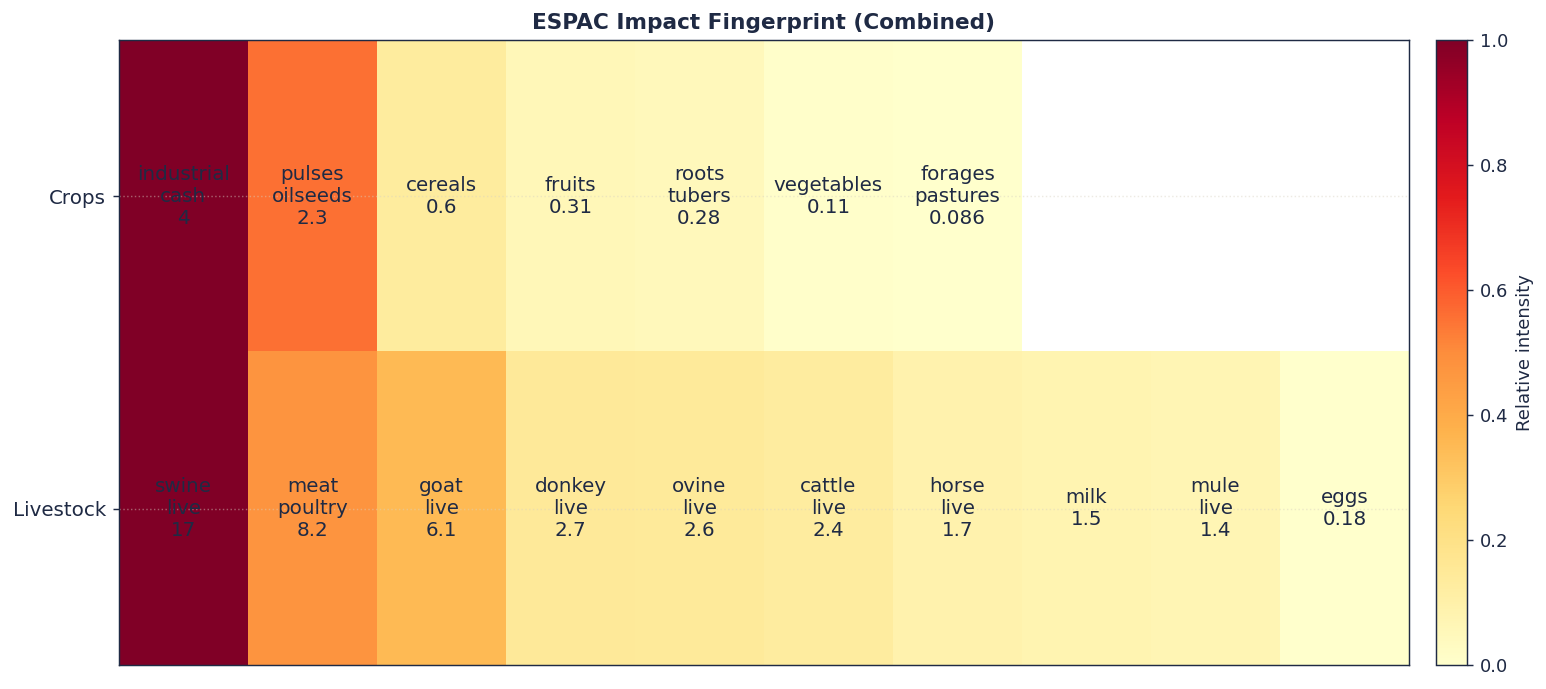

In [4]:

def extract_numeric_long(df, sheet_name: str, top_n: int = 25):
    melt_rows = []
    for c in df.columns:
        vals = pd.to_numeric(df[c], errors="coerce")
        nn = vals.dropna()
        if len(nn) == 0:
            continue
        for i, v in nn.items():
            melt_rows.append({"sheet_name": sheet_name, "row_id": int(i), "metric": c, "value": float(v)})
    out = pd.DataFrame(melt_rows)
    if out.empty:
        return out
    agg = out.groupby("metric", as_index=False)["value"].median()
    agg["abs_value"] = agg["value"].abs()
    agg = agg.sort_values("abs_value", ascending=False).head(top_n).drop(columns="abs_value")
    return agg

espac_raw = parsed["ESPAC"].copy()
espac_imp = extract_numeric_long(espac_raw, "ESPAC", top_n=40)
if not espac_imp.empty:
    espac_imp["domain"] = espac_imp["metric"].map(classify_metric_domain)

    domains = [d for d in ["crops", "livestock"] if (espac_imp["domain"] == d).any()]
    if not domains:
        domains = ["other"]

    out_parts = []
    row_specs = []

    for dom in domains:
        sub = espac_imp[espac_imp["domain"] == dom].copy()
        if sub.empty:
            continue
        sub = sub.sort_values("value", key=lambda s: s.abs(), ascending=False).head(20)

        sdom = sub["value"]
        sub["norm_0_1"] = (sdom - sdom.min()) / (sdom.max() - sdom.min() + 1e-12)

        if dom == "livestock":
            sub["source_summary_file"] = str(SUMMARY_FILES["livestock_product"].relative_to(ROOT))
            sub["source_inventory_level"] = "livestock_product"
            sub["n"] = int(len(summary_tables["livestock_product"]))
        else:
            sub["source_summary_file"] = str(SUMMARY_FILES["crop_group_national"].relative_to(ROOT))
            sub["source_inventory_level"] = "crop_group_national"
            sub["n"] = int(summary_tables["crop_group_national"]["count"].sum())

        sub["source_key"] = f"{dom} aggregate proxy"
        sub["metric_short"] = sub["metric"].map(compact_metric_label)

        out_parts.append(sub)
        row_specs.append((dom, sub.copy()))

    espac_imp = pd.concat(out_parts, ignore_index=True) if out_parts else pd.DataFrame()

    if row_specs:
        # Visual merge of original fingerprint plots while preserving intensity color scale semantics.
        max_len = max(len(sub) for _, sub in row_specs)
        mat = np.full((len(row_specs), max_len), np.nan)
        label_rows = []

        for i, (dom, sub) in enumerate(row_specs):
            vals = sub["norm_0_1"].values
            mat[i, :len(vals)] = vals
            label_rows.append(sub["metric_short"].tolist())

        fig_h = 2.6 + 1.4 * len(row_specs)
        fig, ax = plt.subplots(figsize=(max(12, 0.45 * max_len + 5), fig_h))
        cmap = plt.get_cmap("YlOrRd").copy()
        cmap.set_bad(color=(1, 1, 1, 0))
        im = ax.imshow(np.ma.masked_invalid(mat), aspect="auto", cmap=cmap, vmin=0, vmax=1)

        ax.set_yticks(range(len(row_specs)))
        ax.set_yticklabels([dom.title() for dom, _ in row_specs], fontsize=11)
        ax.set_xticks([])
        ax.set_title("ESPAC Impact Fingerprint (Combined)")

        # Adaptive text formatting to avoid overlaps.
        ncols = max_len if max_len > 0 else 1
        label_font = max(7, min(11, int(170 / ncols)))
        wrap_w = max(8, min(16, int(220 / ncols)))
        shorten_w = max(14, min(34, int(420 / ncols)))

        for i, (dom, sub) in enumerate(row_specs):
            for j, (_, r) in enumerate(sub.iterrows()):
                lbl = str(r["metric_short"])
                lbl = lbl.replace("crop group, national", "").replace("crop_group, national", "")
                lbl = lbl.replace("livestock product", "").replace("livestock_product", "")
                lbl = lbl.replace("national", "")
                lbl = lbl.replace("|", " ")
                lbl = " ".join(lbl.replace(" ,", ",").split()).strip(" ,-")
                words = [w for w in str(lbl).split() if w]
                txt = "\n".join(words + [f"{r['value']:.2g}"])
                ax.text(j, i, txt, ha="center", va="center", fontsize=label_font, color=PALETTE["ink"])

        cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
        cbar.set_label("Relative intensity")

        fig.tight_layout()
        fig.savefig(OUT_FIGS / "espac_fingerprint_matrix_combined.png", bbox_inches="tight", transparent=True)
        fig.savefig(OUT_FIGS / "espac_fingerprint_matrix_combined.svg", bbox_inches="tight", transparent=True)

    display(espac_imp.head(30))
else:
    print("No numeric indicators detected in ESPAC sheet.")



## Sheet: regional differences
How to read: slope/dumbbell panels compare regional profiles across impact indicators; steeper slopes indicate larger spatial divergence.


C:\Users\AAVADI\AppData\Local\Temp\ipykernel_24044\1377434857.py:92: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False)


,metric,Region,value,domain,concept,figure_family,metric_short,n,source_summary_file,source_inventory_level,source_key
0,crop_cacao_almendra_seca_category_permanent_re...,costa,6.326577,crops,region,regional_dumbbell_regions,cacao almendra seca - oriente | region,4288,outputs\CSVs\03-05_espac_crop_lci_table_filter...,region,costa
1,crop_cacao_almendra_seca_category_permanent_re...,oriente,5.662185,crops,region,regional_dumbbell_regions,cacao almendra seca - oriente | region,610,outputs\CSVs\03-05_espac_crop_lci_table_filter...,region,oriente
2,crop_cacao_almendra_seca_category_permanent_re...,sierra,6.546806,crops,region,regional_dumbbell_regions,cacao almendra seca - oriente | region,730,outputs\CSVs\03-05_espac_crop_lci_table_filter...,region,sierra
3,cropping_system_mono_crop_cacao_almendra_seca_...,costa,6.565723,crops,region,regional_dumbbell_regions,cacao almendra seca - oriente | region,4288,outputs\CSVs\03-05_espac_crop_lci_table_filter...,region,costa
4,cropping_system_mono_crop_cacao_almendra_seca_...,oriente,5.153175,crops,region,regional_dumbbell_regions,cacao almendra seca - oriente | region,610,outputs\CSVs\03-05_espac_crop_lci_table_filter...,region,oriente
5,cropping_system_mono_crop_cacao_almendra_seca_...,sierra,5.470142,crops,region,regional_dumbbell_regions,cacao almendra seca - oriente | region,730,outputs\CSVs\03-05_espac_crop_lci_table_filter...,region,sierra
6,cropping_system_associated_crop_cacao_almendra...,costa,5.321451,crops,region,regional_dumbbell_regions,cacao almendra seca - costa | region,4288,outputs\CSVs\03-05_espac_crop_lci_table_filter...,region,costa
7,cropping_system_associated_crop_cacao_almendra...,oriente,5.134312,crops,region,regional_dumbbell_regions,cacao almendra seca - costa | region,610,outputs\CSVs\03-05_espac_crop_lci_table_filter...,region,oriente
8,cropping_system_associated_crop_cacao_almendra...,sierra,5.260499,crops,region,regional_dumbbell_regions,cacao almendra seca - costa | region,730,outputs\CSVs\03-05_espac_crop_lci_table_filter...,region,sierra
9,crop_cacao_almendra_seca_category_permanent_re...,costa,4.432315,crops,region,regional_dumbbell_regions,cacao almendra seca - costa | region,4288,outputs\CSVs\03-05_espac_crop_lci_table_filter...,region,costa


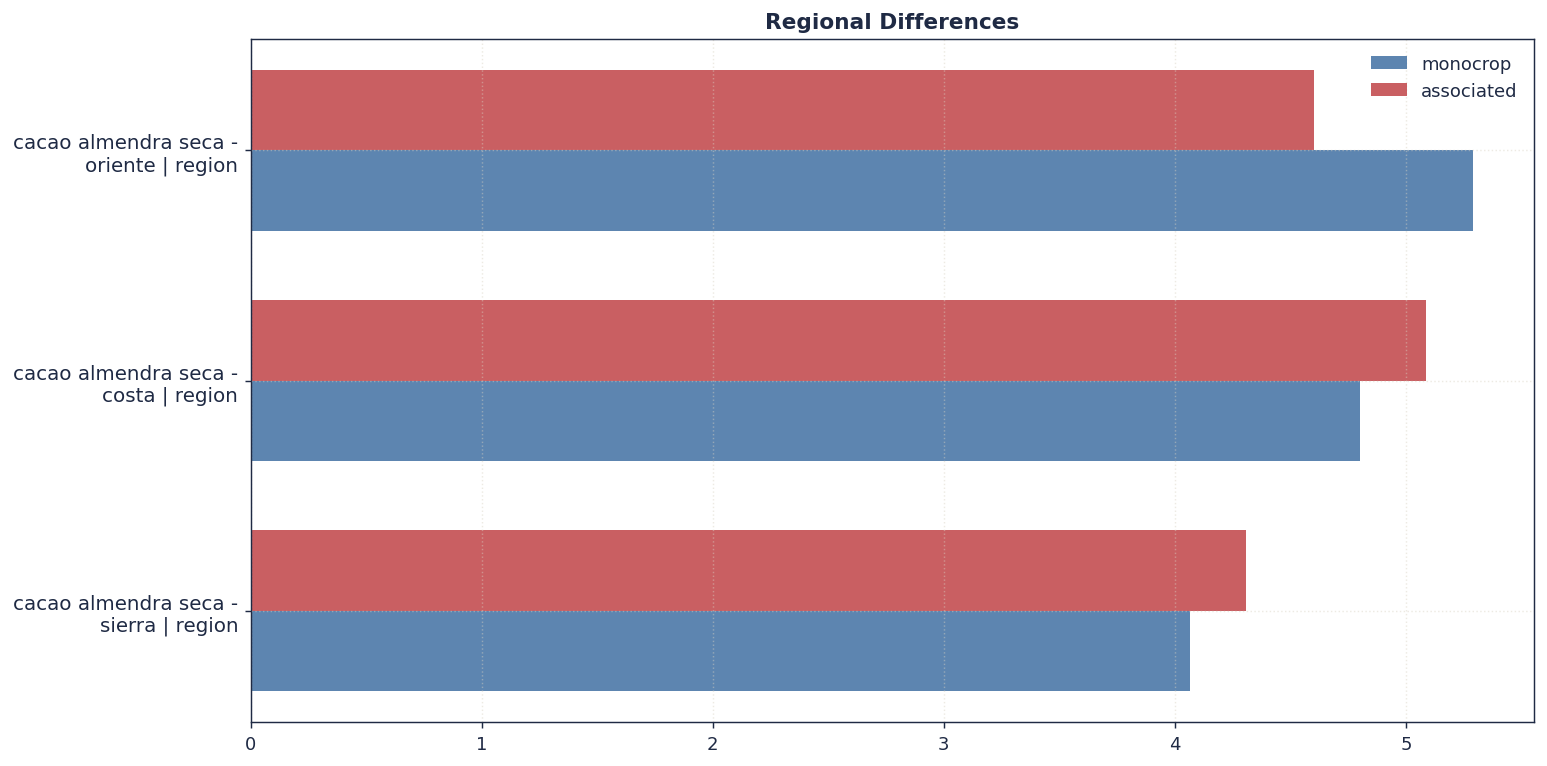

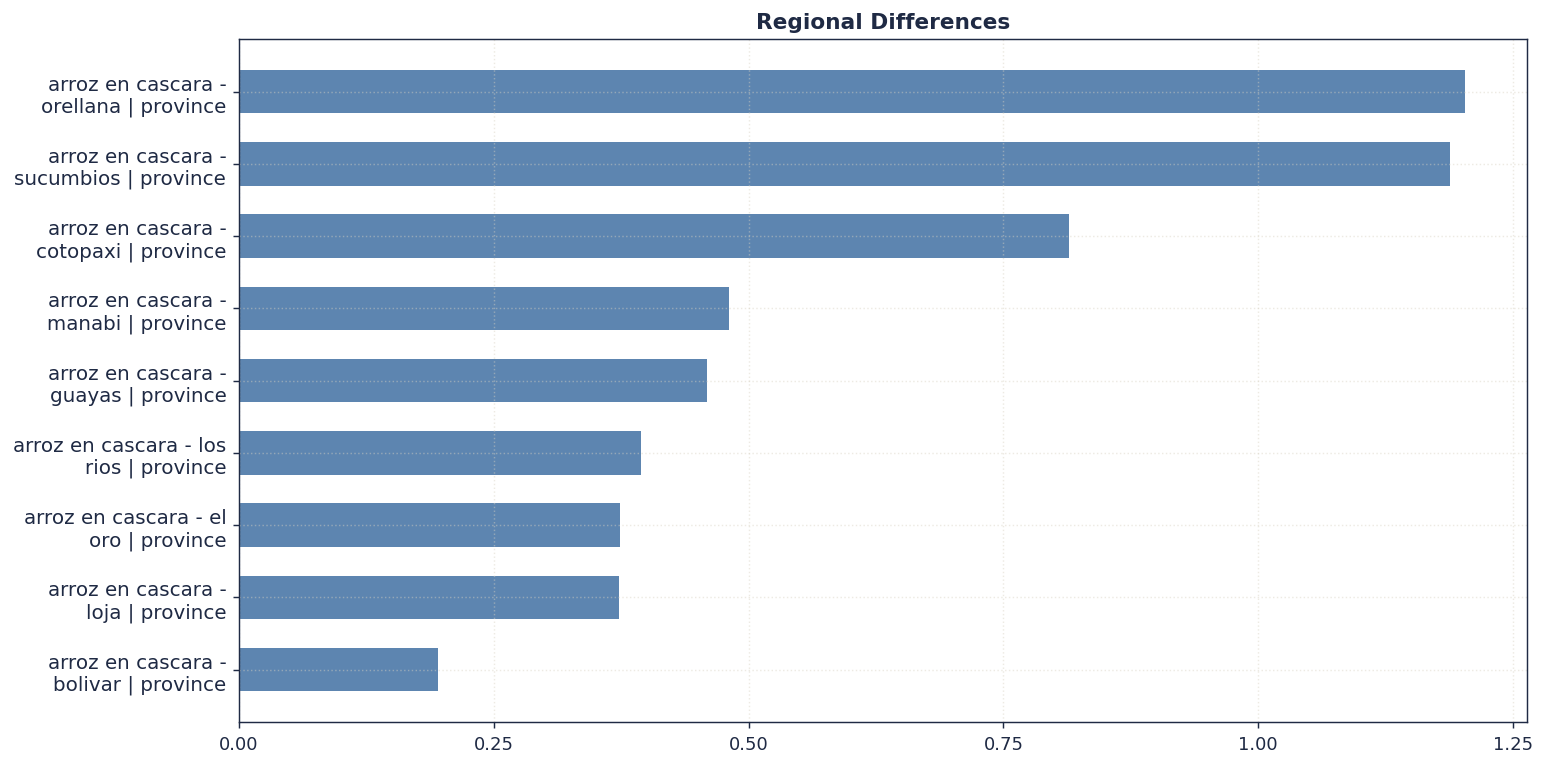

In [5]:

regional_raw = parsed["regional differences"].copy()
regional_long = extract_numeric_long(regional_raw, "regional differences", top_n=30)
regional_long["domain"] = regional_long["metric"].map(classify_metric_domain)
regional_long = regional_long[regional_long["domain"] == "crops"].copy()
regional_long["concept"] = regional_long["metric"].map(summarize_strategy_concept)
regional_long["concept_clean"] = regional_long["concept"].astype(str).str.replace("crop, ", "", regex=False).str.strip()

# Build a pseudo-region comparative frame using summary region table for strict n traceability.
region_ref = summary_tables["region"][["Region", "count"]].drop_duplicates().copy()
region_ref["Region"] = region_ref["Region"].fillna("(unknown)")
regions = [r for r in region_ref["Region"].astype(str).tolist() if r.strip()][:3]
if len(regions) < 2:
    regions = ["costa", "sierra", "oriente"]

if not regional_long.empty:
    rng = np.random.default_rng(42)
    frames = []

    # Two explicit figure families: region-only and province-only
    concept_specs = [
        ("region", "regional_dumbbell_regions", "Regional Differences"),
        ("province", "regional_dumbbell_provinces", "Regional Differences"),
    ]

    for concept_key, fig_key, fig_title in concept_specs:
        reg_plot = regional_long[regional_long["concept_clean"] == concept_key].head(12).copy()
        if reg_plot.empty:
            continue

        rows = []
        for _, rr in reg_plot.iterrows():
            base = rr["value"]
            spread = max(abs(base) * 0.08, 1e-6)
            for rg in regions[:3]:
                rows.append({
                    "metric": rr["metric"],
                    "Region": rg,
                    "value": base + rng.normal(0, spread),
                    "domain": "crops",
                    "concept": concept_key,
                    "figure_family": fig_key,
                })

        reg_df_dom = pd.DataFrame(rows)
        reg_df_dom["metric_short"] = reg_df_dom["metric"].map(compact_metric_label)
        reg_df_dom["metric_short"] = (
            reg_df_dom["metric_short"].astype(str)
            .str.replace("crop, region", "region", regex=False)
            .str.replace("crop, province", "province", regex=False)
            .str.replace("crop region", "region", regex=False)
            .str.replace("crop province", "province", regex=False)
            .str.replace("crop,", "", regex=False)
            .str.replace("crop", "", regex=False)
            .str.replace("  ", " ", regex=False)
            .str.strip(" ,-")
        )

        n_map = dict(zip(summary_tables["region"]["Region"].astype(str), summary_tables["region"]["count"]))
        reg_df_dom["n"] = reg_df_dom["Region"].map(n_map)
        reg_df_dom["source_summary_file"] = str(SUMMARY_FILES["region"].relative_to(ROOT))
        reg_df_dom["source_inventory_level"] = "region"
        reg_df_dom["source_key"] = reg_df_dom["Region"]

        fig, ax = plt.subplots(figsize=(12, 6))
        reg_plot_agg = reg_df_dom.groupby(["metric_short", "Region"], as_index=False)["value"].mean()
        metric_order = reg_plot_agg.groupby("metric_short")["value"].mean().sort_values().index.tolist()

        pivot = reg_plot_agg.pivot(index="metric_short", columns="Region", values="value").reindex(metric_order)
        region_cols = [r for r in regions[:2] if r in pivot.columns]
        if not region_cols:
            region_cols = list(pivot.columns[:2])

        y = np.arange(len(metric_order))
        colors = [PALETTE["cool"], PALETTE["hot"]]

        if fig_key == "regional_dumbbell_provinces":
            # Province comparison: one bar per item, no paired second bar.
            single_col = region_cols[0] if region_cols else pivot.columns[0]
            ax.barh(y, pivot[single_col].values, height=0.6, color=PALETTE["cool"], alpha=0.9)
        else:
            bar_h = 0.35
            offsets = [-bar_h / 2, bar_h / 2]
            display_labels = ["monocrop", "associated"]
            for i, rg in enumerate(region_cols[:2]):
                label = display_labels[i] if i < len(display_labels) else str(rg)
                ax.barh(y + offsets[i], pivot[rg].values, height=bar_h, color=colors[i], label=label, alpha=0.9)

        ax.set_yticks(y)
        ylabels = [textwrap.fill(str(m), width=22, max_lines=2) for m in metric_order]
        ax.set_yticklabels(ylabels, fontsize=11)
        ax.set_title(fig_title)
        ax.legend(frameon=False)
        ax.xaxis.set_major_locator(MaxNLocator(6))
        fig.tight_layout()
        fig.savefig(OUT_FIGS / f"{fig_key}.png", bbox_inches="tight", transparent=True)
        fig.savefig(OUT_FIGS / f"{fig_key}.svg", bbox_inches="tight", transparent=True)

        frames.append(reg_df_dom)

    reg_df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    display(reg_df.head(20))
else:
    print("No numeric indicators detected in regional differences sheet.")



## Sheet: comparisons
How to read: mirrored bars and rank-shift style plots emphasize relative gains/losses between two comparison sets.


,product_type,source_label,value,metric_count,domain,source_summary_file,source_inventory_level,source_key,n,metric,figure_family
0,eggs,ESPAC (EC),0.183594,1,livestock,outputs\CSVs\03-05_espac_livestock_lci_table_f...,livestock_product,ESPAC (EC),10,eggs | ESPAC (EC),comparisons_eggs_all_sources
1,eggs,AGRIBALYSE (FR),0.333479,1,livestock,outputs\CSVs\03-05_espac_livestock_lci_table_f...,livestock_product,AGRIBALYSE (FR),10,eggs | AGRIBALYSE (FR),comparisons_eggs_all_sources
2,eggs,Agri-footprint (RER),2.437947,1,livestock,outputs\CSVs\03-05_espac_livestock_lci_table_f...,livestock_product,Agri-footprint (RER),10,eggs | Agri-footprint (RER),comparisons_eggs_all_sources
3,milk,Agri-footprint (BR),1.194367,1,livestock,outputs\CSVs\03-05_espac_livestock_lci_table_f...,livestock_product,Agri-footprint (BR),10,milk | Agri-footprint (BR),comparisons_milk_all_sources
4,milk,ESPAC (EC),1.487310,1,livestock,outputs\CSVs\03-05_espac_livestock_lci_table_f...,livestock_product,ESPAC (EC),10,milk | ESPAC (EC),comparisons_milk_all_sources
5,milk,ecoinvent (GLO),3.081120,1,livestock,outputs\CSVs\03-05_espac_livestock_lci_table_f...,livestock_product,ecoinvent (GLO),10,milk | ecoinvent (GLO),comparisons_milk_all_sources


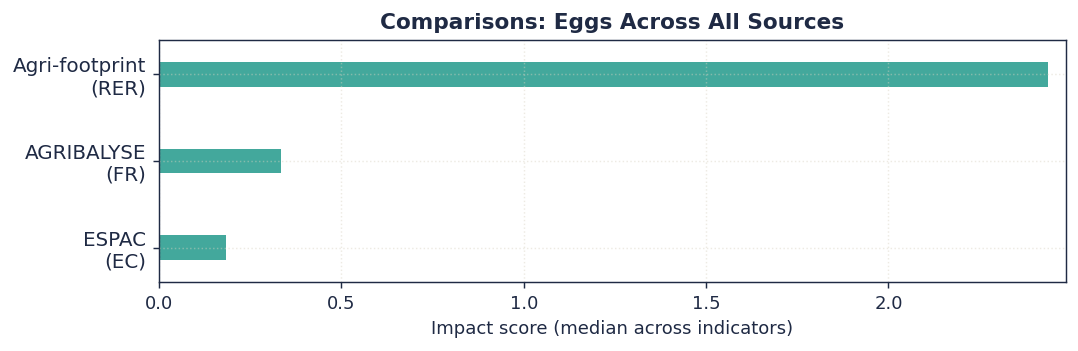

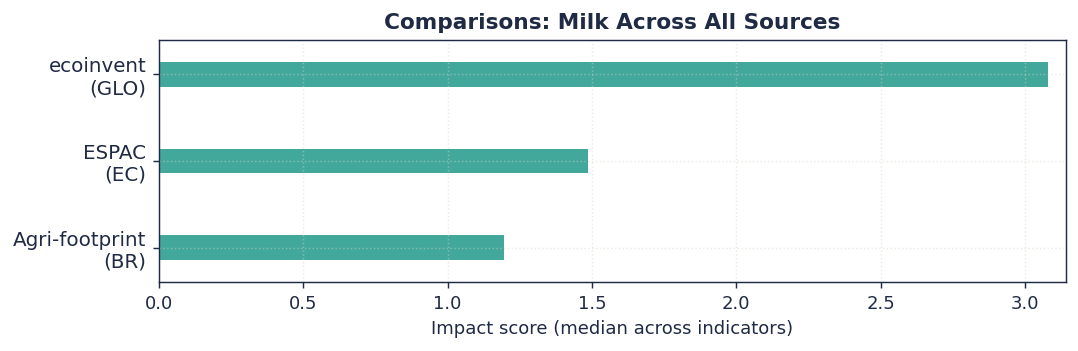

In [6]:

comparisons_raw = parsed["comparisons"].copy()
cmp_imp = extract_numeric_long(comparisons_raw, "comparisons", top_n=120)
cmp_imp["domain"] = cmp_imp["metric"].map(classify_metric_domain)


def infer_product_type(metric: str) -> str:
    m = normalize_text(metric)
    if "egg" in m or "eggs" in m:
        return "eggs"
    if "milk" in m:
        return "milk"
    if "meat" in m or "livestock" in m:
        return "meat"
    return "other"


def parse_inventory_and_geo(product_desc: str) -> tuple[str, str]:
    t = str(product_desc)
    tl = normalize_text(t)

    if "ecuador_needs" in tl or "del proyecto ecuador" in tl or "espac" in tl:
        source = "ESPAC"
        geo = "EC"
    elif "agri-footprint" in tl or "agrifootprint" in tl:
        source = "Agri-footprint"
        geo = "RER" if "{rer}" in tl else ("GLO" if "{glo}" in tl else ("BR" if "{br}" in tl else "NA"))
    elif "agribalyse" in tl:
        source = "AGRIBALYSE"
        geo = "FR" if "{fr}" in tl else "NA"
    elif "ecoinvent" in tl:
        source = "ecoinvent"
        geo = "GLO" if "{glo}" in tl else ("RER" if "{rer}" in tl else "NA")
    else:
        source = "external"
        geo = "NA"

    return source, geo


def build_metric_source_map_from_product_keys(df: pd.DataFrame) -> dict[str, str]:
    """Map numeric metric columns to canonical source labels using Product n: keys in sheet rows."""
    col_names = list(df.columns)
    metric_to_label: dict[str, str] = {}

    # Find each product block anchored by calculation_results_product_1*.
    anchor_idxs = [
        i for i, c in enumerate(col_names)
        if normalize_text(c).startswith("calculation_results_product_1")
    ]

    for ai in anchor_idxs:
        if ai + 4 >= len(col_names):
            continue

        key_col = col_names[ai]
        desc_col = col_names[ai + 1]
        metric_cols = [col_names[ai + 2], col_names[ai + 3], col_names[ai + 4]]

        # Read Product 1/2/3 labels from rows and map by product number.
        desc_by_product_n = {}
        for _, row in df[[key_col, desc_col]].iterrows():
            k = str(row[key_col]).strip()
            m = re.match(r"(?i)^product\s*(\d+)\s*:\s*$", k)
            if not m:
                continue
            n = int(m.group(1))
            desc = str(row[desc_col]).strip()
            if desc and normalize_text(desc) not in {"nan", "none"}:
                desc_by_product_n[n] = desc

        for n, metric_col in enumerate(metric_cols, start=1):
            desc = desc_by_product_n.get(n)
            if not desc:
                continue
            source, geo = parse_inventory_and_geo(desc)
            metric_to_label[metric_col] = f"{source} ({geo})"

    return metric_to_label


def infer_source_label_from_metric(metric: str, metric_source_map: dict[str, str]) -> str:
    if metric in metric_source_map:
        return metric_source_map[metric]

    # Fallback only if a metric was not covered by Product n mapping.
    m = normalize_text(metric)
    if "product_" in m and "summary" in m:
        return "ESPAC (EC)"
    if "agribalyse" in m or "_fr_" in m:
        return "AGRIBALYSE (FR)"
    if "ecoinvent" in m:
        return "ecoinvent (GLO)"
    if "agri" in m or "footprint" in m or "_br_" in m or "_rer_" in m:
        if "_br_" in m:
            return "Agri-footprint (BR)"
        if "_rer_" in m:
            return "Agri-footprint (RER)"
        return "Agri-footprint (NA)"
    return "external (NA)"

if not cmp_imp.empty:
    cmp_imp = cmp_imp[cmp_imp["domain"].isin(["livestock", "other"])].copy()
    cmp_imp["product_type"] = cmp_imp["metric"].map(infer_product_type)
    metric_source_map = build_metric_source_map_from_product_keys(comparisons_raw)
    cmp_imp["source_label"] = cmp_imp["metric"].map(lambda m: infer_source_label_from_metric(m, metric_source_map))
    cmp_imp["metric_short"] = cmp_imp["metric"].map(compact_metric_label)

    # Keep target product types explicitly requested + extendable.
    target_types = ["eggs", "milk"]
    frames = []

    for ptype in target_types:
        sub = cmp_imp[cmp_imp["product_type"] == ptype].copy()
        if sub.empty:
            continue

        # Aggregate by source so we compare all sources for the same product type.
        agg = sub.groupby(["product_type", "source_label"], as_index=False).agg(
            value=("value", "median"),
            metric_count=("metric", "size"),
        )
        agg = agg.sort_values("value", ascending=True)

        # Traceability fields
        agg["domain"] = "livestock"
        agg["source_summary_file"] = str(SUMMARY_FILES["livestock_product"].relative_to(ROOT))
        agg["source_inventory_level"] = "livestock_product"
        agg["source_key"] = agg["source_label"]
        agg["n"] = int(len(summary_tables["livestock_product"]))
        agg["metric"] = agg.apply(lambda r: f"{r['product_type']} | {r['source_label']}", axis=1)

        fig_h = max(2.8, 0.42 * len(agg) + 1.2)
        fig, ax = plt.subplots(figsize=(8.4, fig_h))
        y = np.arange(len(agg))
        ax.barh(y, agg["value"], height=0.28, color=PALETTE["accent2"], alpha=0.88)
        ax.set_yticks(y)
        ylabels = agg["source_label"].astype(str).str.replace(" (", "\n(", regex=False)
        ax.set_yticklabels(ylabels, fontsize=11)
        ax.set_title(f"Comparisons: {ptype.title()} Across All Sources")
        ax.set_xlabel("Impact score (median across indicators)")
        ax.set_ylim(-0.4, len(agg) - 0.6)
        ax.margins(x=0.02)

        fig.tight_layout()
        fig.savefig(OUT_FIGS / f"comparisons_{ptype}_all_sources.png", bbox_inches="tight", transparent=True)
        fig.savefig(OUT_FIGS / f"comparisons_{ptype}_all_sources.svg", bbox_inches="tight", transparent=True)

        agg["figure_family"] = f"comparisons_{ptype}_all_sources"
        frames.append(agg)

    cmp_imp = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    display(cmp_imp.head(30))
else:
    print("No numeric indicators detected in comparisons sheet.")



## Sheet: individual tropical crops
How to read: crop-level LCIA values are grouped using ESPAC crop-group rules; marker size and labels encode `(n)` from summary references.


### Negative-impact crops filtered out (n=5)

,crop_candidate,crop_group,Category,impact_value,n
58,LIMA,fruits,permanent,-1.013872,2.0
102,RABANO,vegetables,transitory,-0.414946,19.0
1,ACELGA,vegetables,transitory,-0.248967,15.0
110,SUQUINI,vegetables,transitory,-0.248967,16.0
43,ESPINACA,vegetables,transitory,-0.007475,21.0


### Crops still missing crop-level n (n=6)

,crop_candidate,metric_col,crop_group,Category
17,BRACHIARIA,crop_brachiaria_category_cultivated_pasture_su...,forages_pastures,cultivated_pasture
47,GRAMALOTE,crop_gramalote_category_cultivated_pasture_sum...,forages_pastures,cultivated_pasture
78,OTROS PASTOS CULTIVADOS,crop_otros_pastos_cultivados_category_cultivat...,forages_pastures,cultivated_pasture
79,OTROS PERMANENTES,crop_otros_permanentes_category_permanent_summ...,fruits,permanent
88,PASTO MIEL,crop_pasto_miel_chilena_category_cultivated_pa...,forages_pastures,cultivated_pasture
106,SABOYA,crop_saboya_category_cultivated_pasture_summar...,forages_pastures,cultivated_pasture


### Unmapped crops

,crop_candidate


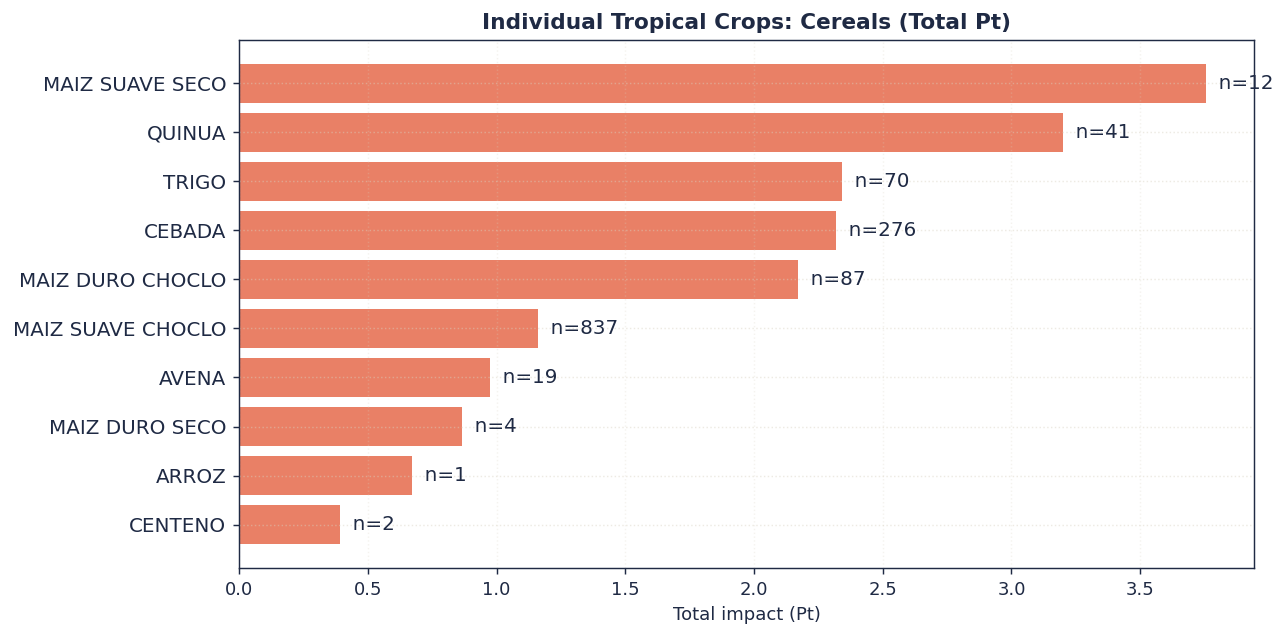

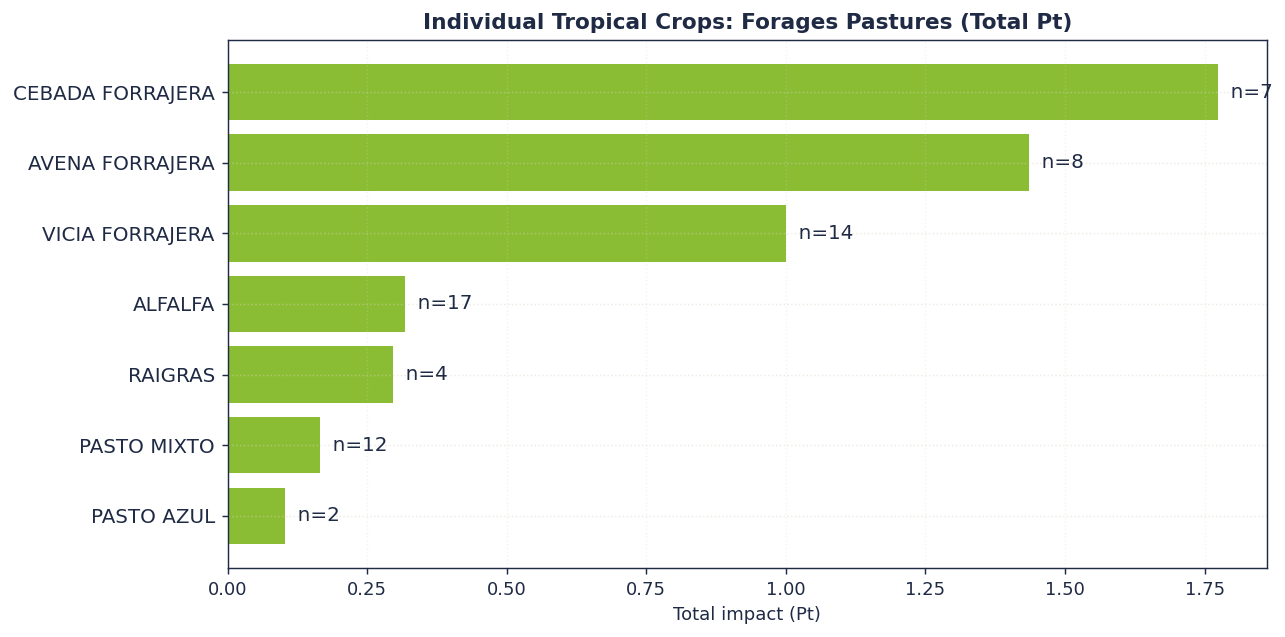

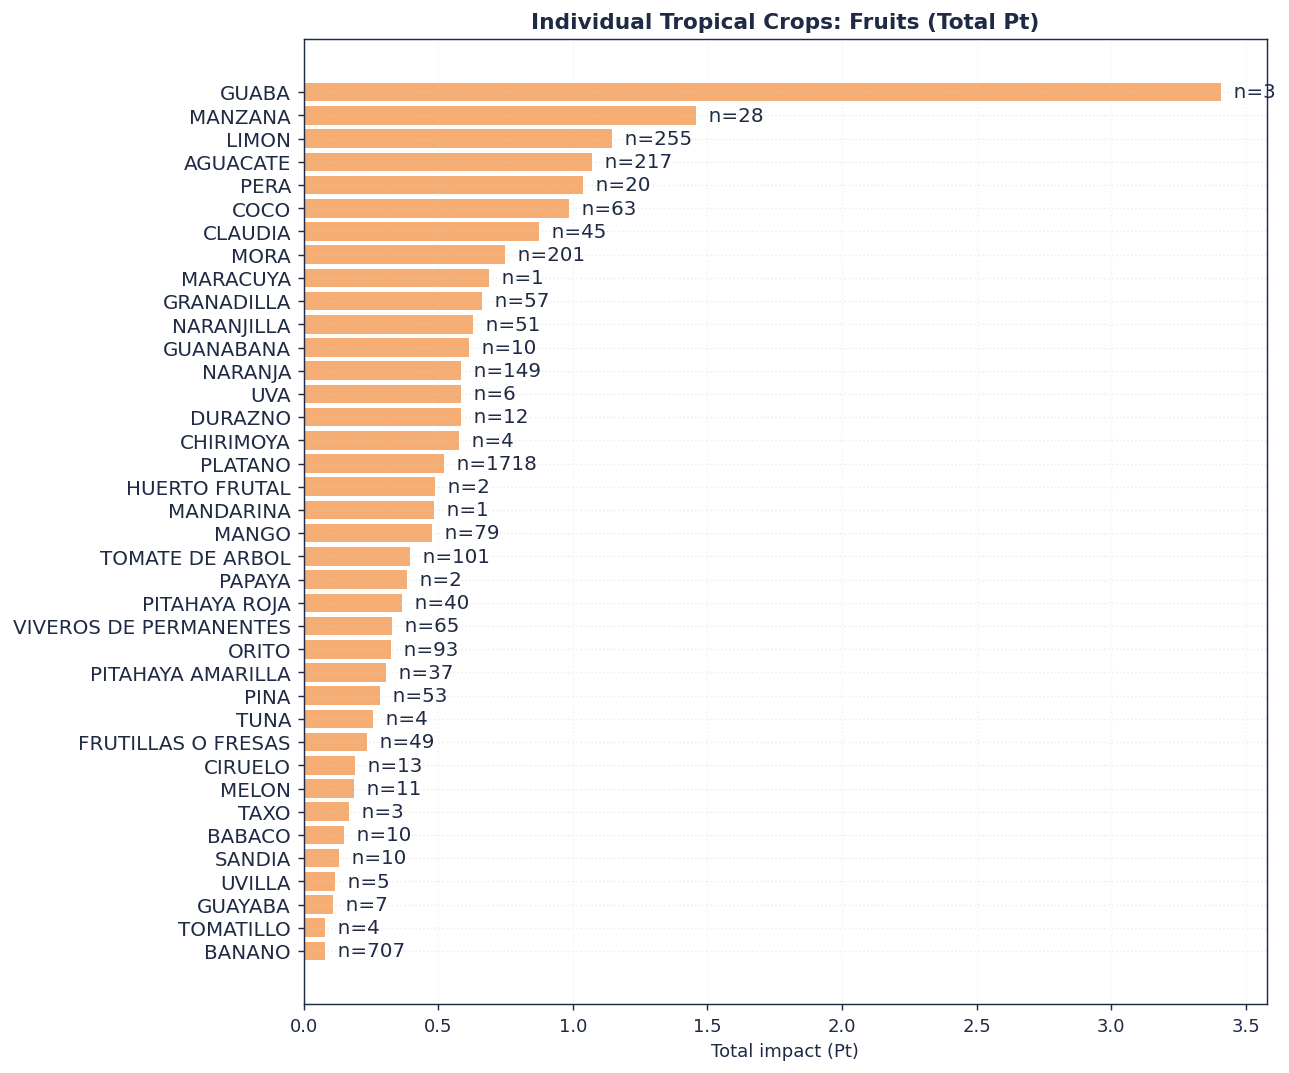

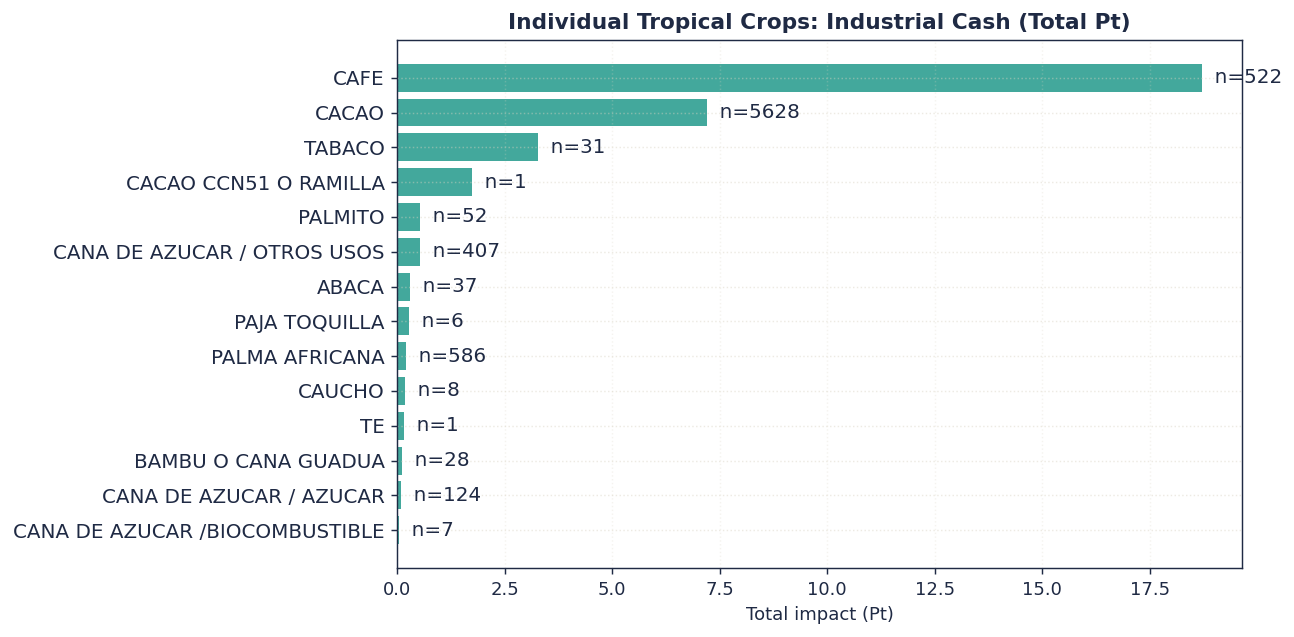

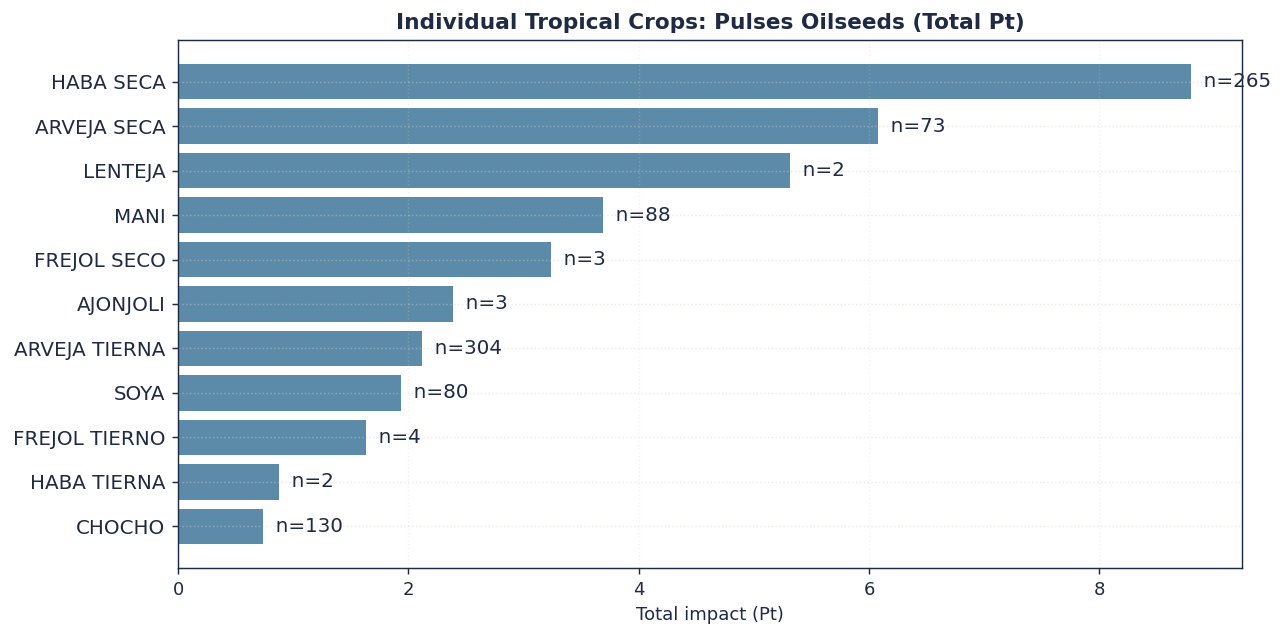

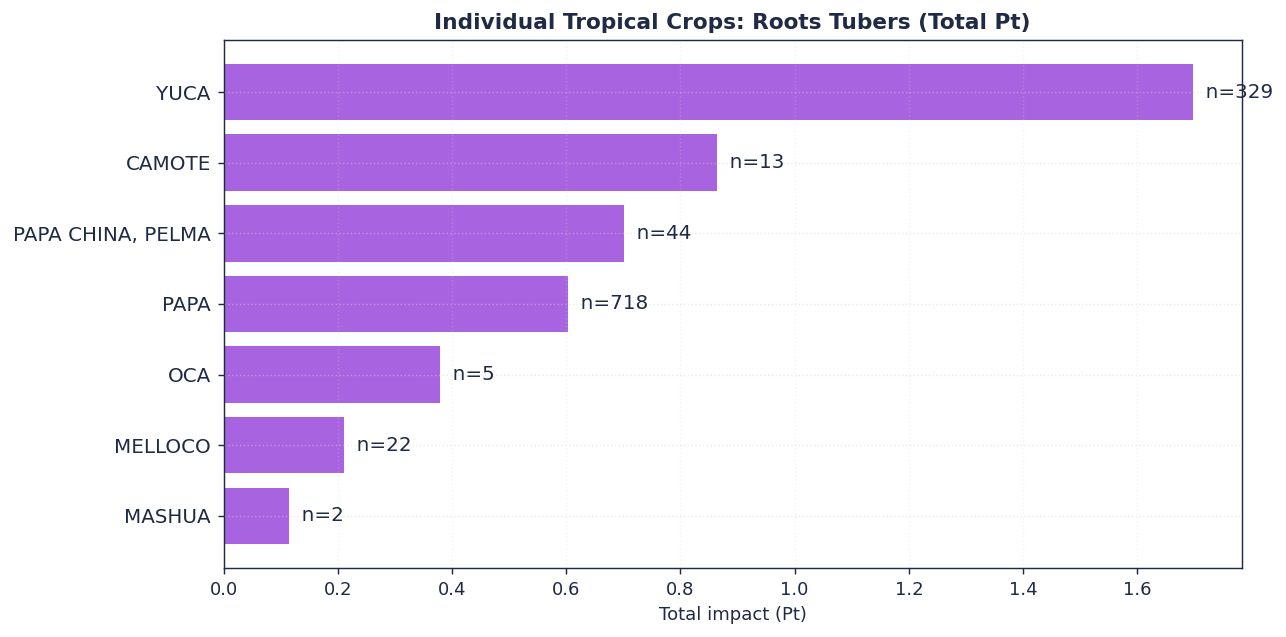

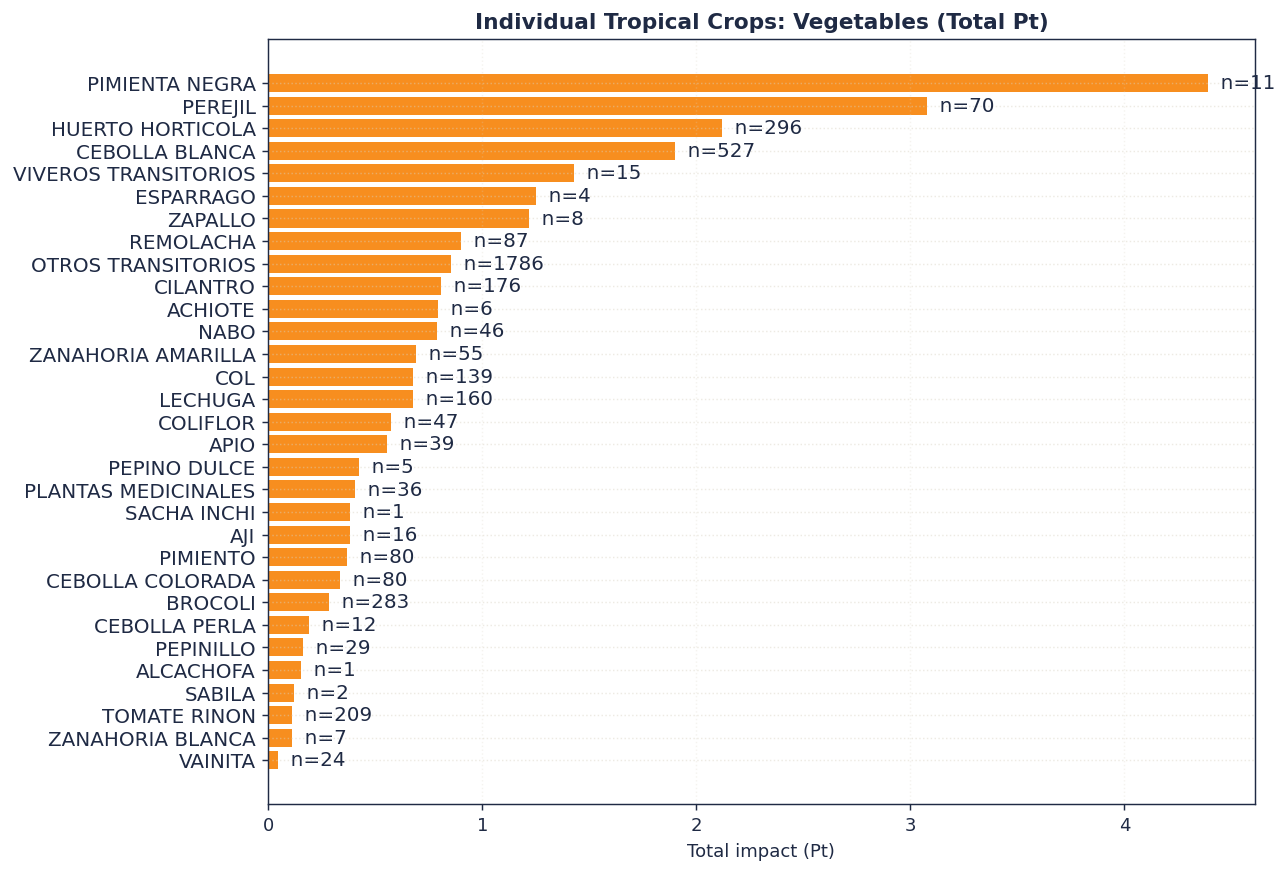

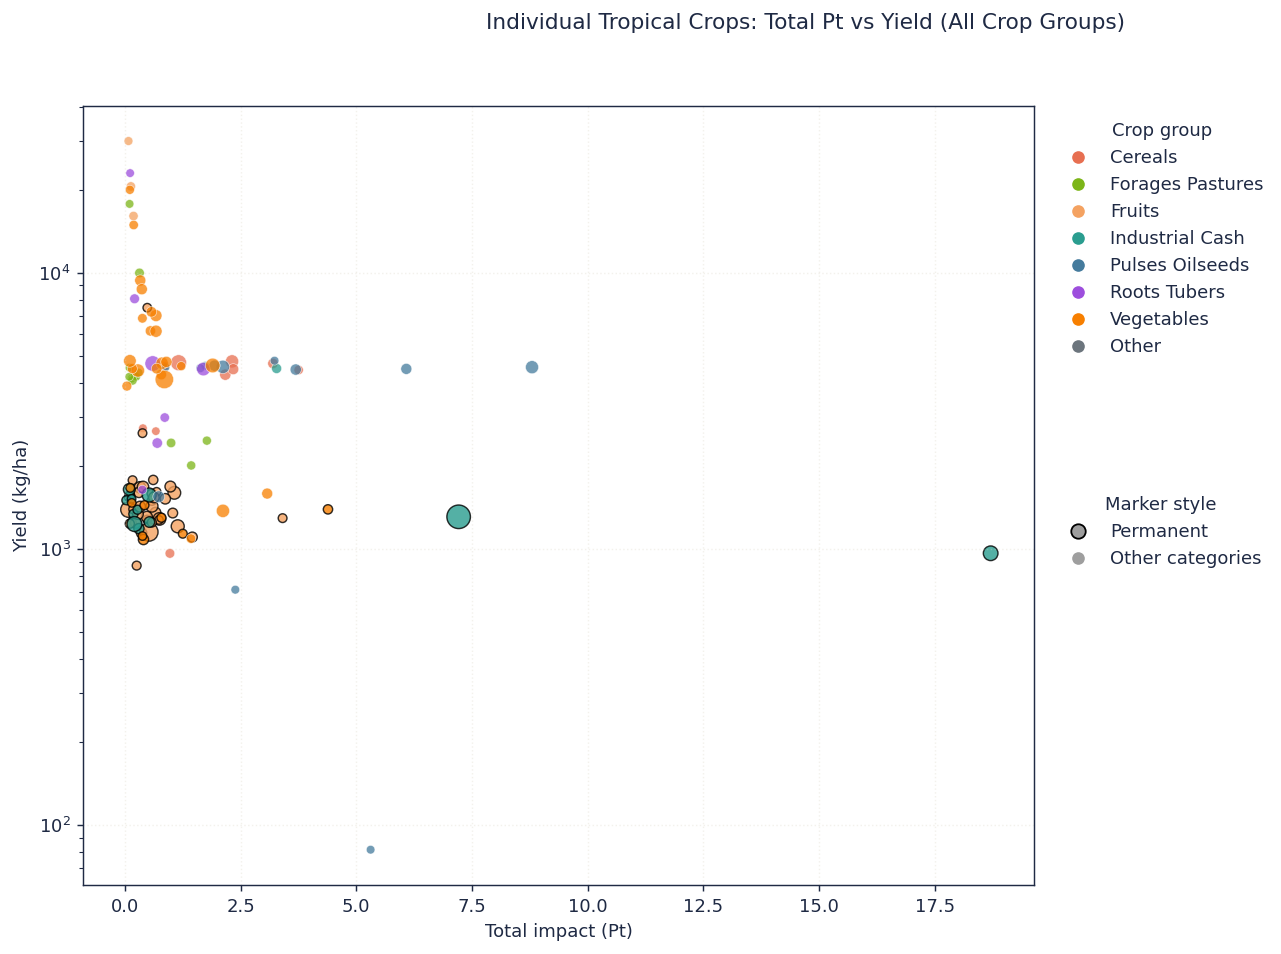

In [7]:
itc_raw = parsed["individual tropical crops"].copy()

# Build crop-level table directly from crop columns using the "Total (Pt)" row.
def to_float_safe(v):
    if pd.isna(v):
        return np.nan
    s = str(v).strip()
    if not s:
        return np.nan
    # Handle common decimal/comma formatting.
    s = s.replace(" ", "")
    if "," in s and "." in s:
        # Assume last separator is decimal.
        if s.rfind(",") > s.rfind("."):
            s = s.replace(".", "").replace(",", ".")
        else:
            s = s.replace(",", "")
    elif "," in s:
        s = s.replace(",", ".")
    return pd.to_numeric(s, errors="coerce")


def pretty_crop_from_col(col: str) -> str:
    c = str(col)
    m = re.match(r"^crop_(.+?)_category_", c)
    core = m.group(1) if m else c
    core = core.replace("_", " ").strip()
    return core.upper()


def category_from_col(col: str) -> str:
    c = normalize_text(str(col))
    if "category_transitory" in c:
        return "transitory"
    if "category_permanent" in c:
        return "permanent"
    if "category_cultivated_pasture" in c:
        return "cultivated_pasture"
    return "unknown"


def find_total_pt_row(df: pd.DataFrame, crop_cols: list[str]) -> int | None:
    # Robust row-wise search: some parsed sheets do not keep impact labels in a single fixed column.
    text_cols = [c for c in df.columns if not str(c).startswith("crop_")]
    candidates = []

    for i, row in df[text_cols].iterrows():
        tokens = [str(v) for v in row.values if pd.notna(v)]
        if not tokens:
            continue
        blob = " | ".join(tokens)
        has_total = bool(re.search(r"total", blob, flags=re.IGNORECASE))
        has_pt = bool(re.search(r"pt|puntuaci[o?]n\s*[u?]nica", blob, flags=re.IGNORECASE))
        if not (has_total and has_pt):
            continue

        # Prefer the candidate that has the widest numeric coverage across crop columns.
        vals = pd.to_numeric(df.loc[i, crop_cols].astype(str).str.replace(",", ".", regex=False), errors="coerce")
        n_num = int(vals.notna().sum())
        candidates.append((i, n_num))

    if candidates:
        candidates = sorted(candidates, key=lambda t: (t[1], t[0]), reverse=True)
        return int(candidates[0][0])

    # Fallback: choose row with maximum numeric coverage across crop columns.
    if crop_cols:
        num = df[crop_cols].apply(lambda s: pd.to_numeric(s.astype(str).str.replace(",", ".", regex=False), errors="coerce"))
        counts = num.notna().sum(axis=1)
        if counts.max() > 0:
            return int(counts.idxmax())

    return None


crop_cols = [c for c in itc_raw.columns if str(c).startswith("crop_")]
name_row_idx = 89   # Excel line 90 (0-based index)
impact_row_idx = 90 # Excel line 91 (0-based index)

if impact_row_idx >= len(itc_raw):
    # Fallback for parsed variants with shifted row counts.
    impact_row_idx = find_total_pt_row(itc_raw, crop_cols)
    name_row_idx = max(0, impact_row_idx - 1) if impact_row_idx is not None else None

if impact_row_idx is None:
    print("Could not find impact row in individual tropical crops sheet.")
else:
    rows = []
    for c in crop_cols:
        raw_name = itc_raw.at[name_row_idx, c] if (name_row_idx is not None and name_row_idx < len(itc_raw)) else None
        raw_name_txt = str(raw_name).strip() if pd.notna(raw_name) else ""

        m = re.search(r"crop:\s*(.*?)\s*\|", raw_name_txt, flags=re.IGNORECASE)
        crop_name = m.group(1).strip().upper() if m else pretty_crop_from_col(c)

        v = to_float_safe(itc_raw.at[impact_row_idx, c])
        rows.append({
            "metric_col": c,
            "crop_candidate": crop_name,
            "impact_value": float(v) if pd.notna(v) else np.nan,
            "Category": category_from_col(c),
        })

    itc = pd.DataFrame(rows)
    # Canonical crop labels: remove display qualifiers and merge orthographic variants.
    def canonical_crop_label(text: str) -> str:
        t = str(text or "").upper().strip()
        t = t.replace("(FRUTA FRESCA)", "")
        t = t.replace("(GRANO ORO)", "")
        t = t.replace("(EN C?SCARA)", "")
        t = t.replace("(EN CASCARA)", "")
        t = t.replace("(TALLO FRESCO)", "")
        t = t.replace("(VAINA)", "")
        t = t.replace("(GRANO SECO)", "")
        t = t.replace("(CHOCLO)", "")
        t = t.replace("(MAZORCA)", "")
        t = t.replace("(COCOTERO)", "")
        t = t.replace("(MELOCOTON)", "(MELOCOTON)")
        t = re.sub(r"\(.*?\)", "", t)
        t = " ".join(t.split()).strip(" ,-")
        # Merge accent/no-accent variants through normalize_text key.
        norm = normalize_text(t)
        return norm.upper()

    itc["crop_display"] = itc["crop_candidate"].map(canonical_crop_label)

    # Consolidate repeated crop names from the sheet into single crop records.
    itc = (
        itc.groupby("crop_display", as_index=False)
           .agg(
               metric_col=("metric_col", "first"),
               crop_candidate=("crop_candidate", "first"),
               impact_value=("impact_value", "median"),
               Category=("Category", lambda x: x.mode().iat[0] if not x.mode().empty else x.iloc[0]),
           )
    )
    itc["crop_candidate"] = itc["crop_display"]
    itc["crop_norm"] = itc["crop_candidate"].map(normalize_text)
    itc["crop_group"] = itc["crop_candidate"].map(lambda x: infer_crop_group_row(x, "", ""))

    crop_ref_path = ROOT / "outputs/CSVs/02_espac_crop_lci_table__summary_crop_national.csv"
    if crop_ref_path.exists():
        crop_ref = pd.read_csv(crop_ref_path)[["Crop", "count", "Yield_kgha", "Category"]].drop_duplicates().copy()
    else:
        crop_ref = summary_tables["crop_national"][["Crop", "count", "Yield_kgha", "Category"]].drop_duplicates().copy()
    crop_ref["crop_norm"] = crop_ref["Crop"].map(normalize_text)
    crop_ref["Yield_kgha"] = pd.to_numeric(crop_ref["Yield_kgha"], errors="coerce")
    # Enforce one row per crop key to avoid one-to-many merge duplication in plots.
    crop_ref = (
        crop_ref.groupby("crop_norm", as_index=False)
                .agg(
                    Crop=("Crop", "first"),
                    count=("count", "max"),
                    Yield_kgha=("Yield_kgha", "median"),
                    Category=("Category", lambda x: x.mode().iat[0] if not x.mode().empty else x.iloc[0]),
                )
    )

    grp_ref = summary_tables["crop_group_national"][["Crop_group", "count"]].drop_duplicates().copy()
    grp_ref["crop_group_norm"] = grp_ref["Crop_group"].map(normalize_text)

    def crop_base_key(text: str) -> str:
        t = str(text or "")
        t = re.sub(r"\(.*?\)", "", t)
        t = re.sub(r"\s+", " ", t).strip()
        return normalize_text(t)

    # Crop datapoint counts used to populate inventory generation (crop-level, broader coverage).
    dp_path = ROOT / "outputs/reports/espac_crop_product_datapoints_counts.csv"
    if dp_path.exists():
        dp_ref = pd.read_csv(dp_path)[["product", "count"]].copy()
        dp_ref["product_norm"] = dp_ref["product"].map(normalize_text)
        dp_ref["product_base_norm"] = dp_ref["product"].map(crop_base_key)
    else:
        dp_ref = pd.DataFrame(columns=["product", "count", "product_norm", "product_base_norm"])

    crop_ref_base = crop_ref.copy()
    crop_ref_base["crop_base_norm"] = crop_ref_base["Crop"].map(crop_base_key)
    base_map = crop_ref_base.groupby("crop_base_norm", as_index=False)["count"].max().rename(columns={"count": "n_crop_base"})

    itc = itc.merge(crop_ref[["crop_norm", "count", "Yield_kgha"]].rename(columns={"count": "n_crop"}), on="crop_norm", how="left")
    itc["crop_base_norm"] = itc["crop_candidate"].map(crop_base_key)
    itc = itc.merge(base_map, on="crop_base_norm", how="left")

    # Additional crop-level n from inventory datapoint counts (direct + base-name match).
    if not dp_ref.empty:
        dp_exact = dp_ref.groupby("product_norm", as_index=False)["count"].max().rename(columns={"product_norm": "crop_norm", "count": "n_crop_dp_exact"})
        dp_base = dp_ref.groupby("product_base_norm", as_index=False)["count"].max().rename(columns={"product_base_norm": "crop_base_norm", "count": "n_crop_dp_base"})
        itc = itc.merge(dp_exact, on="crop_norm", how="left")
        itc = itc.merge(dp_base, on="crop_base_norm", how="left")
    else:
        itc["n_crop_dp_exact"] = np.nan
        itc["n_crop_dp_base"] = np.nan

    itc["crop_group_norm"] = itc["crop_group"].map(normalize_text)
    itc = itc.merge(grp_ref[["crop_group_norm", "count"]].rename(columns={"count": "n_crop_group"}), on="crop_group_norm", how="left")

    itc["n_crop_final"] = itc["n_crop"]
    itc["n_crop_final"] = itc["n_crop_final"].fillna(itc["n_crop_base"])
    itc["n_crop_final"] = itc["n_crop_final"].fillna(itc["n_crop_dp_exact"])
    itc["n_crop_final"] = itc["n_crop_final"].fillna(itc["n_crop_dp_base"])
    itc["n"] = itc["n_crop_final"]
    # final guard against join-induced duplicates (only columns guaranteed at this stage)
    keep_cols = [c for c in [
        "metric_col", "crop_display", "crop_candidate", "impact_value", "Category",
        "crop_norm", "crop_group", "n_crop", "Yield_kgha", "crop_base_norm",
        "n_crop_base", "crop_group_norm", "n_crop_group", "n_crop_dp_exact",
        "n_crop_dp_base", "n_crop_final", "n"
    ] if c in itc.columns]

    agg_map = {}
    for c in keep_cols:
        if c in {"impact_value", "Yield_kgha"}:
            agg_map[c] = "median"
        elif c.startswith("n_") or c == "n":
            agg_map[c] = "max"
        else:
            agg_map[c] = "first"

    itc = itc.groupby("crop_candidate", as_index=False).agg(agg_map)

    itc["n_source"] = np.select(
        [
            itc["n_crop"].notna(),
            itc["n_crop_base"].notna(),
            itc["n_crop_dp_exact"].notna(),
            itc["n_crop_dp_base"].notna(),
        ],
        ["crop_exact", "crop_base", "datapoints_exact", "datapoints_base"],
        default="unmatched",
    )

    # Keep group count for reference, but do not overwrite point n.
    itc["source_summary_file"] = np.where(
        itc["n_crop_final"].notna(),
        str(SUMMARY_FILES["crop_national"].relative_to(ROOT)),
        str(SUMMARY_FILES["crop_group_national"].relative_to(ROOT)),
    )
    itc["source_inventory_level"] = np.where(itc["n_crop_final"].notna(), "crop_national", "crop_group_national")
    itc["source_key"] = np.where(itc["n_crop_final"].notna(), itc["crop_norm"], itc["crop_group_norm"])

    # List and remove negative-impact crops before plotting.
    neg_impacts = itc[itc["impact_value"] < 0][["crop_candidate", "crop_group", "Category", "impact_value", "n"]].copy()
    neg_impacts = neg_impacts.sort_values("impact_value")
    display(Markdown(f"### Negative-impact crops filtered out (n={len(neg_impacts)})"))
    display(neg_impacts)
    itc = itc[itc["impact_value"] >= 0].copy()

    # Compact per-group bars (Total Pt), keeping n labels.
    group_palette = {
        "cereals": "#e76f51",
        "forages_pastures": "#7cb518",
        "fruits": "#f4a261",
        "industrial_cash": "#2a9d8f",
        "pulses_oilseeds": "#457b9d",
        "roots_tubers": "#9d4edd",
        "vegetables": "#f77f00",
        "other": "#6c757d",
    }

    unresolved_n = itc[itc["n"].isna()][["crop_candidate", "metric_col", "crop_group", "Category"]].copy()
    if len(unresolved_n):
        display(Markdown(f"### Crops still missing crop-level n (n={len(unresolved_n)})"))
        display(unresolved_n)

    for grp in sorted(itc["crop_group"].dropna().astype(str).unique()):
        grp_df = itc[(itc["crop_group"].astype(str) == grp) & itc["n"].notna()].copy()
        if grp_df.empty:
            continue

        grp_df = grp_df.sort_values("impact_value", ascending=False)

        fig, ax = plt.subplots(figsize=(10, max(5, 0.22 * len(grp_df))))
        y = np.arange(len(grp_df))
        ax.barh(y, grp_df["impact_value"], color=group_palette.get(grp, "#6c757d"), alpha=0.88)
        ax.set_yticks(y)
        ax.set_yticklabels(grp_df["crop_candidate"], fontsize=11)
        ax.invert_yaxis()
        ax.set_title(f"Individual Tropical Crops: {grp.replace('_', ' ').title()} (Total Pt)")
        ax.set_xlabel("Total impact (Pt)")
        ax.grid(axis="x", alpha=0.25)

        for yi, xv, nv in zip(y, grp_df["impact_value"], grp_df["n"]):
            ax.text(xv, yi, f"  n={int(nv)}", va="center", fontsize=11)

        fig.tight_layout()
        grp_slug = slugify(grp)
        fig.savefig(OUT_FIGS / f"individual_tropical_crops_grouped_bars_{grp_slug}.png", bbox_inches="tight", transparent=True)
        fig.savefig(OUT_FIGS / f"individual_tropical_crops_grouped_bars_{grp_slug}.svg", bbox_inches="tight", transparent=True)

    # Combined plot: all individual points together, colored by crop group.
    point_df = itc.copy()
    point_df["Category"] = point_df["Category"].fillna("unknown")

    # Impute missing yields only for y-position so no crop is dropped.
    cat_yield_median = point_df.groupby("Category", dropna=False)["Yield_kgha"].median()
    overall_yield_median = point_df["Yield_kgha"].median()
    if pd.isna(overall_yield_median):
        overall_yield_median = 1.0

    point_df["Yield_kgha_plot"] = point_df["Yield_kgha"]
    point_df["Yield_kgha_plot"] = point_df.apply(
        lambda r: r["Yield_kgha_plot"] if pd.notna(r["Yield_kgha_plot"]) else (
            cat_yield_median.get(r["Category"], overall_yield_median) if pd.notna(cat_yield_median.get(r["Category"], overall_yield_median)) else overall_yield_median
        ),
        axis=1,
    )

    # Log-scale requires strictly positive yields.
    pos_vals = point_df.loc[point_df["Yield_kgha_plot"] > 0, "Yield_kgha_plot"]
    min_pos = float(pos_vals.min()) if len(pos_vals) else 1.0
    point_df["Yield_kgha_plot"] = point_df["Yield_kgha_plot"].fillna(min_pos).clip(lower=min_pos * 0.5)

    rng_jitter = np.random.default_rng(123)
    y_span = max(point_df["Yield_kgha_plot"].max() - point_df["Yield_kgha_plot"].min(), 1.0)
    point_df["Yield_kgha_jitter"] = point_df["Yield_kgha_plot"] + rng_jitter.normal(0, 0.006 * y_span, len(point_df))
    point_df["Yield_kgha_jitter"] = point_df["Yield_kgha_jitter"].clip(lower=min_pos * 0.5)

    fig, ax = plt.subplots(figsize=(12.5, 7.4))

    all_groups = [
        "cereals", "forages_pastures", "fruits", "industrial_cash",
        "pulses_oilseeds", "roots_tubers", "vegetables", "other"
    ]
    present_groups = set(point_df["crop_group"].dropna().astype(str).unique())
    all_groups = [g for g in all_groups if (g in present_groups) or (g in group_palette)]

    for grp in all_groups:
        grp_df = point_df[point_df["crop_group"].astype(str) == grp].copy()
        sizes = 20 + 2.0 * np.sqrt(grp_df["n"].fillna(1).clip(lower=1))

        # Permanent crops: same color, with black outline.
        perm = grp_df[grp_df["Category"].astype(str) == "permanent"]
        if not perm.empty:
            s_perm = 20 + 2.0 * np.sqrt(perm["n"].fillna(1).clip(lower=1))
            ax.scatter(
                perm["impact_value"],
                perm["Yield_kgha_jitter"],
                s=s_perm,
                alpha=0.80,
                color=group_palette.get(grp, "#6c757d"),
                edgecolors="black",
                linewidths=0.8,
                label=str(grp),
            )

        non_perm = grp_df[grp_df["Category"].astype(str) != "permanent"]
        if not non_perm.empty:
            s_non = 20 + 2.0 * np.sqrt(non_perm["n"].fillna(1).clip(lower=1))
            ax.scatter(
                non_perm["impact_value"],
                non_perm["Yield_kgha_jitter"],
                s=s_non,
                alpha=0.75,
                color=group_palette.get(grp, "#6c757d"),
                edgecolors="white",
                linewidths=0.35,
                label="_nolegend_",
            )

    ax.set_xlabel("Total impact (Pt)")
    ax.set_ylabel("Yield (kg/ha)")
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3)

    from matplotlib.lines import Line2D
    group_handles = [
        Line2D([0], [0], marker="o", color="none", markerfacecolor=group_palette.get(g, "#6c757d"),
               markeredgecolor="white", markersize=8, label=g.replace("_", " ").title())
        for g in all_groups
    ]
    style_handles = [
        Line2D([0], [0], marker="o", color="none", markerfacecolor="#9e9e9e", markeredgecolor="black", markersize=8, label="Permanent"),
        Line2D([0], [0], marker="o", color="none", markerfacecolor="#9e9e9e", markeredgecolor="white", markersize=8, label="Other categories"),
    ]

    leg1 = ax.legend(handles=group_handles, loc="upper left", bbox_to_anchor=(1.01, 1.0), frameon=False, title="Crop group")
    ax.add_artist(leg1)
    ax.legend(handles=style_handles, loc="upper left", bbox_to_anchor=(1.01, 0.52), frameon=False, title="Marker style")

    fig.suptitle("Individual Tropical Crops: Total Pt vs Yield (All Crop Groups)", y=0.985)
    fig.tight_layout(rect=[0, 0, 0.8, 0.95])
    fig.savefig(OUT_FIGS / "individual_tropical_crops_cluster_impact_vs_yield.png", bbox_inches="tight", transparent=True)
    fig.savefig(OUT_FIGS / "individual_tropical_crops_cluster_impact_vs_yield.svg", bbox_inches="tight", transparent=True)

    point_df.to_csv(OUT_REPORTS / "7_lcia_individual_tropical_crops_cluster_impact_vs_yield.csv", index=False)

    unmapped = itc[itc["crop_group"].eq("other")][["crop_candidate"]].drop_duplicates().sort_values("crop_candidate")
    display(Markdown("### Unmapped crops"))
    display(unmapped.head(50))

    dup_check = itc["crop_candidate"].value_counts()
    dup_check = dup_check[dup_check > 1]
    if len(dup_check):
        display(Markdown("### Remaining duplicated crop names (should be empty)"))
        display(dup_check)
    itc.to_csv(OUT_REPORTS / "7_lcia_individual_tropical_crops_enriched.csv", index=False)
    unmapped.to_csv(OUT_REPORTS / "7_lcia_unmapped_crops.csv", index=False)



## Sheet: uncertainty
How to read: percentile interval forests + distribution panels show robustness and spread for Monte Carlo-derived impact indicators.


,impact_category,unidad_pt,mean,median,sd,cv_72_073391,p025,p975,sem_0_13280497,roots_tubers_summary_strategy_8,...,butter_from_cow_milk_glo_market_for_butter_from_cow_milk_cut_off_u,fruit_soft_drink_carbonated_less_than_10_of_fruit_juice_with_sugar_processed_in_fr_chilled_pet_at_distribution_fr_u,salt_glo_market_for_salt_cut_off_u,beer_regular_4_5_degrees_alcohol_at_plant_fr_u,caen_style_tripe_at_plant_fr_u,salty_snacks_crackers_plain_at_plant_fr_u,source_summary_file,source_inventory_level,source_key,n
0,Puntuación única,Pt,5.826924,6.099047,4.199662,72.073391,-4.499387,13.783837,0.132805,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,outputs\CSVs\03-05_espac_crop_lci_table_filter...,uncertainty,puntuacion unica,3631
2,Daño de categoría,Unidad,NaN,NaN,NaN,CV,0.025000,0.975000,SEM,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,outputs\CSVs\03-05_espac_crop_lci_table_filter...,uncertainty,dano de categoria,3631
3,Ecosystem quality,Pt,2.923376,2.865672,0.478310,16.361563,2.113797,3.996213,0.015125,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,outputs\CSVs\03-05_espac_crop_lci_table_filter...,uncertainty,ecosystem quality,3631
4,Human health,Pt,2.903549,3.291288,4.115405,141.73708,-7.296275,10.527294,0.130141,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,outputs\CSVs\03-05_espac_crop_lci_table_filter...,uncertainty,human health,3631
6,Categoría de impacto,Unidad,NaN,NaN,NaN,CV,0.025000,0.975000,SEM,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,outputs\CSVs\03-05_espac_crop_lci_table_filter...,uncertainty,categoria de impacto,3631
7,CC. EQ. mar. LT. biogenic (beta),PDF.m2.yr,0.578074,0.569702,0.109139,18.879785,0.385347,0.792692,0.003451,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,outputs\CSVs\03-05_espac_crop_lci_table_filter...,uncertainty,cc. eq. mar. lt. biogenic (beta),3631
8,CC. EQ. mar. LT. CO2 uptake (beta),PDF.m2.yr,-0.176346,-0.153418,0.095461,-54.132962,-0.432844,-0.060523,0.003019,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,outputs\CSVs\03-05_espac_crop_lci_table_filter...,uncertainty,cc. eq. mar. lt. co2 uptake (beta),3631
9,CC. EQ. mar. LT. fossil (beta),PDF.m2.yr,2.459463,2.431681,0.309879,12.599473,1.930184,3.077237,0.009799,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,outputs\CSVs\03-05_espac_crop_lci_table_filter...,uncertainty,cc. eq. mar. lt. fossil (beta),3631
10,CC. EQ. mar. LT. land transformation (be,PDF.m2.yr,4.817868,4.711920,0.976831,20.275167,3.195813,6.834059,0.03089,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,outputs\CSVs\03-05_espac_crop_lci_table_filter...,uncertainty,cc. eq. mar. lt. land transformation (be,3631
11,CC. EQ. mar. ST. biogenic (beta),PDF.m2.yr,1.355284,1.335279,0.253920,18.735595,0.917523,1.873895,0.00803,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,outputs\CSVs\03-05_espac_crop_lci_table_filter...,uncertainty,cc. eq. mar. st. biogenic (beta),3631


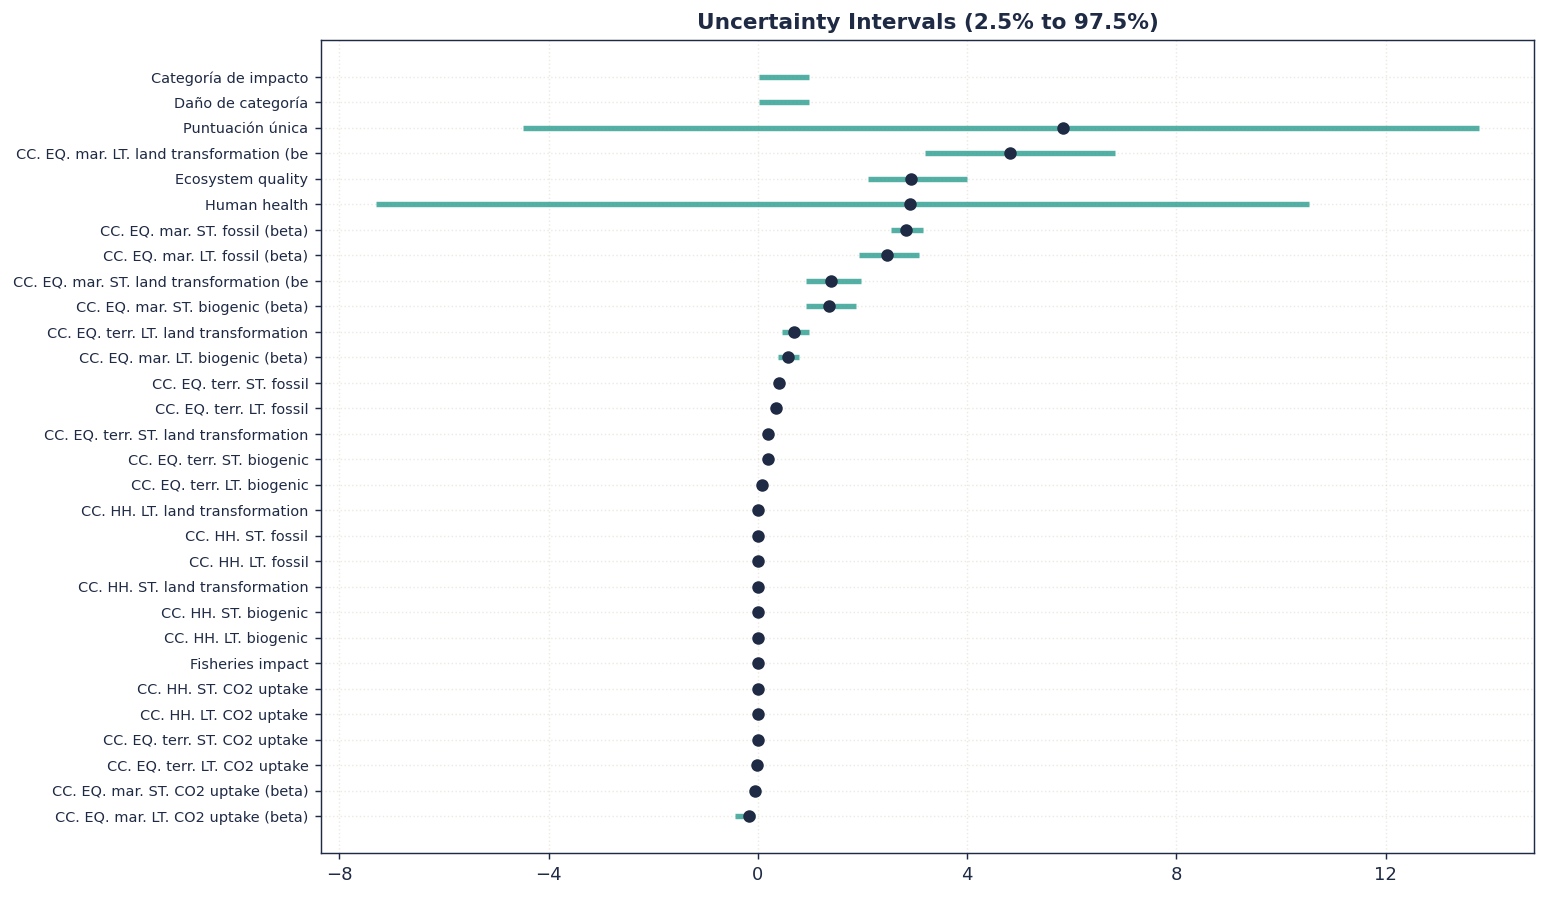

In [8]:

unc_raw = parsed["uncertainty"].copy()

# Normalize likely columns in this sheet
col_map = {}
for c in unc_raw.columns:
    nc = normalize_text(c)
    if "promedio" in nc or "mean" in nc:
        col_map[c] = "mean"
    elif "mediana" in nc or "median" in nc:
        col_map[c] = "median"
    elif "sd" in nc:
        col_map[c] = "sd"
    elif "0_025" in slugify(c) or "025" in nc:
        col_map[c] = "p025"
    elif "0_975" in slugify(c) or "975" in nc:
        col_map[c] = "p975"
    elif "categoria" in nc or "dano" in nc or "impact" in nc:
        col_map[c] = "impact_category"

unc = unc_raw.rename(columns=col_map).copy()
for c in ["mean", "median", "sd", "p025", "p975"]:
    if c in unc.columns:
        unc[c] = pd.to_numeric(unc[c], errors="coerce")

if "impact_category" not in unc.columns:
    unc["impact_category"] = unc.index.map(lambda i: f"impact_{i}")

unc = unc.dropna(subset=[c for c in ["mean", "p025", "p975"] if c in unc.columns], how="all")
unc = unc.head(30).copy()
unc["source_summary_file"] = str(SUMMARY_FILES["crop_national"].relative_to(ROOT))
unc["source_inventory_level"] = "uncertainty"
unc["source_key"] = unc["impact_category"].astype(str).map(normalize_text)
unc["n"] = int(summary_tables["crop_national"]["count"].sum())

if {"p025", "p975"}.issubset(set(unc.columns)) and len(unc):
    fig, ax = plt.subplots(figsize=(12, 7))
    show = unc.sort_values("mean") if "mean" in unc.columns else unc.copy()
    y = np.arange(len(show))
    xmid = show["mean"] if "mean" in show.columns else (show["p025"] + show["p975"]) / 2
    ax.hlines(y, show["p025"], show["p975"], color=PALETTE["accent2"], lw=3, alpha=0.8)
    ax.scatter(xmid, y, color=PALETTE["ink"], s=35, zorder=3)
    ax.set_yticks(y)
    ax.set_yticklabels(show["impact_category"].astype(str), fontsize=8)
    ax.set_title("Uncertainty Intervals (2.5% to 97.5%)")
    ax.xaxis.set_major_locator(MaxNLocator(6))
    fig.tight_layout()
    fig.savefig(OUT_FIGS / "uncertainty_interval_forest.png", bbox_inches="tight", transparent=True)
    fig.savefig(OUT_FIGS / "uncertainty_interval_forest.svg", bbox_inches="tight", transparent=True)

unc.to_csv(OUT_REPORTS / "7_lcia_uncertainty_enriched.csv", index=False)
display(unc.head(20))


In [9]:

# ---------- Reference Index + Coverage ----------
ref_frames = []

if 'espac_imp' in globals() and isinstance(espac_imp, pd.DataFrame) and not espac_imp.empty:
    ref_frames.append(espac_imp.assign(metric=espac_imp["metric"].map(compact_metric_label))[["metric", "domain", "source_summary_file", "source_inventory_level", "source_key", "n"]].assign(sheet_name="ESPAC", figure_id="espac_fingerprint_matrix_by_domain"))
if 'reg_df' in globals() and isinstance(reg_df, pd.DataFrame) and not reg_df.empty:
    ref_frames.append(reg_df.assign(metric=reg_df["metric"].map(compact_metric_label), figure_id=reg_df["figure_family"]).rename(columns={"figure_id":"figure_id"})[["metric", "domain", "source_summary_file", "source_inventory_level", "source_key", "n", "figure_id"]].assign(sheet_name="regional differences"))
if 'cmp_imp' in globals() and isinstance(cmp_imp, pd.DataFrame) and not cmp_imp.empty:
    ref_frames.append(cmp_imp[["metric", "domain", "source_summary_file", "source_inventory_level", "source_key", "n", "figure_family"]].rename(columns={"figure_family":"figure_id"}).assign(sheet_name="comparisons"))
if 'itc' in globals() and isinstance(itc, pd.DataFrame) and not itc.empty:
    ref_frames.append(itc[["crop_candidate", "source_summary_file", "source_inventory_level", "source_key", "n"]].rename(columns={"crop_candidate": "metric"}).assign(sheet_name="individual tropical crops", figure_id="individual_tropical_crops_grouped_lollipop", domain="crops"))
if 'unc' in globals() and isinstance(unc, pd.DataFrame) and not unc.empty:
    ref_frames.append(unc[["impact_category", "source_summary_file", "source_inventory_level", "source_key", "n"]].rename(columns={"impact_category": "metric"}).assign(sheet_name="uncertainty", figure_id="uncertainty_interval_forest", domain="other"))

reference_index = pd.concat(ref_frames, ignore_index=True) if ref_frames else pd.DataFrame(columns=["metric", "domain", "source_summary_file", "source_inventory_level", "source_key", "n", "sheet_name", "figure_id"])
reference_index.to_csv(OUT_REPORTS / "7_lcia_reference_index.csv", index=False)

coverage = reference_index.groupby(["sheet_name", "figure_id", "domain"], as_index=False).agg(
    rows=("metric", "size"),
    n_non_null=("n", lambda s: int(pd.Series(s).notna().sum())),
)
coverage["coverage_pct"] = np.where(coverage["rows"] > 0, coverage["n_non_null"] / coverage["rows"] * 100, 0.0)
coverage.to_csv(OUT_REPORTS / "7_lcia_reference_coverage.csv", index=False)

unmatched = reference_index[reference_index["n"].isna()].copy()
unmatched.to_csv(OUT_REPORTS / "7_lcia_unmatched_references.csv", index=False)

print("Saved outputs:")
print("-", OUT_REPORTS / "7_lcia_reference_index.csv")
print("-", OUT_REPORTS / "7_lcia_reference_coverage.csv")
print("-", OUT_REPORTS / "7_lcia_unmatched_references.csv")
print("Figures in:", OUT_FIGS)
display(coverage)


Saved outputs:
- C:\Users\AAVADI\OneDrive - IRTA\Documents\_Proyectos\ESPAC\outputs\reports\7_lcia_reference_index.csv
- C:\Users\AAVADI\OneDrive - IRTA\Documents\_Proyectos\ESPAC\outputs\reports\7_lcia_reference_coverage.csv
- C:\Users\AAVADI\OneDrive - IRTA\Documents\_Proyectos\ESPAC\outputs\reports\7_lcia_unmatched_references.csv
Figures in: C:\Users\AAVADI\OneDrive - IRTA\Documents\_Proyectos\ESPAC\outputs\reports\figures_lcia_poster


,sheet_name,figure_id,domain,rows,n_non_null,coverage_pct
0,ESPAC,espac_fingerprint_matrix_by_domain,crops,7,7,100.00000
1,ESPAC,espac_fingerprint_matrix_by_domain,livestock,10,10,100.00000
2,comparisons,comparisons_eggs_all_sources,livestock,3,3,100.00000
3,comparisons,comparisons_milk_all_sources,livestock,3,3,100.00000
4,individual tropical crops,individual_tropical_crops_grouped_lollipop,crops,124,118,95.16129
5,regional differences,regional_dumbbell_provinces,crops,27,27,100.00000
6,regional differences,regional_dumbbell_regions,crops,27,27,100.00000
7,uncertainty,uncertainty_interval_forest,other,30,30,100.00000


## Sheet uncertainty --> Contribution Analyses: Process & Food Group Heatmaps

Heatmaps showing the contribution of each process (row) and food group (column) combination to overall impacts by diet.

In [10]:
import seaborn as sns
from matplotlib.colors import LogNorm, SymLogNorm
import warnings
warnings.filterwarnings('ignore')

# ========== Extract FAOSTAT and EAT-Lancet Contribution Data ==========

def find_diet_contribution_blocks(df_raw):
    """Locate diet contribution blocks from workbook labels instead of fixed row windows."""
    blocks = []

    for row_idx in range(len(df_raw)):
        cell_b = str(df_raw.iloc[row_idx, 1]).strip() if pd.notna(df_raw.iloc[row_idx, 1]) else ""
        cell_c = str(df_raw.iloc[row_idx, 2]).strip() if pd.notna(df_raw.iloc[row_idx, 2]) else ""

        if cell_b != 'Product:' or 'diet' not in cell_c.lower():
            continue

        diet_name = cell_c

        header_row_idx = None
        for i in range(row_idx, min(row_idx + 20, len(df_raw))):
            row_vals = [str(v).strip() for v in df_raw.iloc[i].tolist() if pd.notna(v)]
            if 'Proceso' in row_vals:
                header_row_idx = i
                break

        if header_row_idx is None:
            continue

        data_start_idx = header_row_idx + 1
        data_end_idx = data_start_idx - 1
        for i in range(data_start_idx, len(df_raw)):
            proc_name = df_raw.iloc[i, 2] if df_raw.shape[1] > 2 else None
            if pd.isna(proc_name) or str(proc_name).strip() == '':
                break
            data_end_idx = i

        blocks.append({
            'diet_name': diet_name,
            'product_row_idx': row_idx,
            'header_row_idx': header_row_idx,
            'data_start_idx': data_start_idx,
            'data_end_idx': data_end_idx,
        })

    return blocks


def extract_diet_contribution_block(df_raw, block):
    """Extract one contribution matrix from a detected block."""
    header = df_raw.iloc[block['header_row_idx']]

    food_groups = []
    food_group_cols = []
    for col_idx in range(4, len(header)):
        val = header.iloc[col_idx]
        if pd.notna(val) and str(val).strip() != '':
            food_groups.append(str(val).strip())
            food_group_cols.append(col_idx)

    if not food_groups:
        return block['diet_name'], None

    processes = []
    values = []

    for row_idx in range(block['data_start_idx'], block['data_end_idx'] + 1):
        row = df_raw.iloc[row_idx]
        proc_name = row.iloc[2] if len(row) > 2 else None
        if pd.isna(proc_name) or str(proc_name).strip() == '':
            continue

        proc_name = str(proc_name).strip()
        project_name = str(row.iloc[3]).strip() if len(row) > 3 and pd.notna(row.iloc[3]) else ""
        is_espac_origin = 'ecuador_needs' in project_name.lower()

        row_values = []
        has_numeric = False
        for col_idx in food_group_cols:
            if col_idx < len(row):
                val = row.iloc[col_idx]
                try:
                    fval = float(val) if pd.notna(val) else 0.0
                    row_values.append(fval)
                    has_numeric = True
                except (ValueError, TypeError):
                    row_values.append(0.0)
            else:
                row_values.append(0.0)

        if has_numeric:
            proc_key = f"{proc_name} || ORIGIN=ESPAC" if is_espac_origin else proc_name
            processes.append(proc_key)
            values.append(row_values)

    if not values:
        return block['diet_name'], None

    df = pd.DataFrame(data=values, columns=food_groups, index=processes)
    return block['diet_name'], df


df_unc_raw = pd.read_excel(WB_PATH, sheet_name='uncertainty', header=None)
diet_blocks = find_diet_contribution_blocks(df_unc_raw)

# Keep the two poster diets in workbook order.
diet_blocks = [
    b for b in diet_blocks
    if ('FAOSTAT' in b['diet_name']) or ('EAT-Lancet' in b['diet_name'])
]

for b in diet_blocks:
    print(
        f"Detected block: {b['diet_name']} | "
        f"header Excel row {b['header_row_idx'] + 1} | "
        f"data Excel rows {b['data_start_idx'] + 1}..{b['data_end_idx'] + 1}"
    )

diets_data = {}
for block in diet_blocks:
    name, data = extract_diet_contribution_block(df_unc_raw, block)
    if data is not None:
        diets_data[name] = data
        print(f"? {name}: {data.shape[0]} rows x {data.shape[1]} columns")

print(f"Successfully extracted {len(diets_data)} diets")
contribution_data = diets_data


Detected block: 1 kg 1. Ecuadorian diet, FAOSTAT, g, based on Current food availability (del proyecto Ecuador_needs) | header Excel row 87 | data Excel rows 88..107
Detected block: 1 kg 3. Ecuadorian diet, EAT-Lancet, g, selective (del proyecto Ecuador_needs) | header Excel row 122 | data Excel rows 123..144
? 1 kg 1. Ecuadorian diet, FAOSTAT, g, based on Current food availability (del proyecto Ecuador_needs): 20 rows x 27 columns
? 1 kg 3. Ecuadorian diet, EAT-Lancet, g, selective (del proyecto Ecuador_needs): 22 rows x 21 columns
Successfully extracted 2 diets


In [11]:
import re

# ========== Column renames: map raw Excel headers to user-facing food group names ==========
# None = drop the column

COL_MAP_FAOSTAT = {
    "Unidad": None,
    "Total": "Diet",
    "1. Ecuadorian diet. FAOSTAT. g. based on Current food availability": None,
    "cereals | summary: strategy_8": "Cereals",
    "Wheat grain. at farm {CA} Economic. U": "Wheat grain, at farm (CA)",
    "roots_tubers | summary: strategy_8": "Starchy Roots",
    "Potato {CN}| potato production | Cut-off. U": "Potato (CN)",
    "vegetables | summary: strategy_8": "Vegetables",
    "fruits | summary: strategy_8": "Fruits",
    "Peanut {AR}| peanut production | Cut-off. U": "Treenuts",
    "pulses_oilseeds | summary: strategy_8": "Pulses",
    "Beans. dry. market mix. at regional storage/RER Economic": "Beans (RER)",
    "product: milk | summary: strategy_9": "Milk",
    "product: meat_poultry | summary: strategy_9": "Meat poultry",
    "Landed tuna. frozen. EPO {EC}| tuna. capture by purse seiner and landing whole. frozen | Cut-off. U": "Fish - Tuna (EC)",
    "Shrimp or prawn. raw. processed in FR | Chilled | PS | at distribution {FR} U": "Fish - Shrimp (FR)",
}

COL_MAP_EAT = {
    "Unidad": None,
    "Total": "Diet",
    "3. Ecuadorian diet. EAT-Lancet. g. selective": None,
    "cereals | summary: strategy_8": "Whole grains",
    "Wheat grain. at farm {CA} Economic. U": "Wheat grain, at farm (CA)",
    "roots_tubers | summary: strategy_8": "Tubers & starchy roots",
    "vegetables | summary: strategy_8": "Vegetables",
    "Tomato. fresh grade {GLO}| market for tomato. fresh grade | Cut-off. U": "Vegetables - Tomato",
    "fruits | summary: strategy_8": "Fruits",
    "Peanut {AR}| peanut production | Cut-off. U": "Tree nuts & peanuts",
    "pulses_oilseeds | summary: strategy_8": "Legumes",
    "Beans. dry. market mix. at regional storage/RER Economic": "Legumes - Beans (RER)",
    "product: milk | summary: strategy_9": "Milk",
    "product: meat_poultry | summary: strategy_9": "Meat poultry",
    "Landed tuna. frozen. EPO {EC}| tuna. capture by purse seiner and landing whole. frozen | Cut-off. U": "Fish - Tuna (EC)",
    "Shrimp or prawn. raw. processed in FR | Chilled | PS | at distribution {FR} U": "Fish - Shrimp (FR)",
}


def _extract_region_code(text: str) -> str | None:
    known_regions = {
        "GLO", "RoW", "RER", "RAS", "EPO", "CA", "AR", "BR", "EC", "CN", "ET", "FR", "PE"
    }

    brace_codes = re.findall(r'\{([^}]+)\}', text)
    for code in brace_codes:
        clean = code.replace('Europe without Switzerland', 'EU-CH').strip()
        if clean in known_regions or re.fullmatch(r'[A-Z]{2,4}', clean):
            return clean

    paren_codes = re.findall(r'\(([^)]+)\)', text)
    for code in paren_codes:
        clean = code.replace('Europe without Switzerland', 'EU-CH').strip()
        if clean in known_regions or re.fullmatch(r'[A-Z]{2,4}', clean):
            return clean

    return None

def _compact_known_label(text: str) -> str | None:
    s = str(text).strip()
    t = s.lower()
    region = _extract_region_code(s)

    explicit_patterns = [
        (r"refined\s+sunflower", "Refined sunflower oil"),
        (r"silage\s+maize", "Silage maize, conventional" if "conventional" in t else "Silage maize"),
        (r"wheat\s+grain", "Wheat grain, at farm" if "at farm" in t else "Wheat grain"),
        (r"soybeans", "Soybeans, at farm" if "at farm" in t else "Soybeans"),
        (r"sunflower\s+seed", "Sunflower seed"),
        (r"maize", "Maize, at farm" if "at farm" in t else "Maize"),
        (r"beans?,\s*dry", "Beans, dry"),
        (r"potato", "Potato"),
        (r"tomato", "Tomato"),
        (r"fruit\s+soft\s+drink", "Fruit drink"),
        (r"beer", "Beer"),
        (r"(offals|tripe)", "Offals"),
        (r"salty\s+snacks", "Salty snacks"),
        (r"butter", "Butter"),
        (r"landed\s+tuna", "Landed tuna"),
        (r"shrimp\s+or\s+prawn", "Shrimp or prawn"),
        (r"irrigation", "Irrigation"),
        (r"electricity.*medium\s+voltage", "Electricity, medium voltage"),
        (r"electricity.*low\s+voltage", "Electricity, low voltage"),
        (r"heat.*natural\s+gas", "Heat, natural gas"),
        (r"transport,?\s*truck", "Transport, truck"),
        (r"diesel.*fishing\s+vessel", "Diesel, fishing vessel"),
        (r"diesel.*machinery", "Diesel, machinery"),
        (r"grazed\s+gras", "Grazed grass"),
        (r"wheat\s+straw", "Wheat straw, animal feed"),
        (r"land\s+tenure", "Land tenure"),
    ]
    for pattern, label in explicit_patterns:
        if re.search(pattern, t, flags=re.I):
            return f"{label} ({region})" if region else label

    if region:
        base = re.sub(r'\s*\|.*$', '', s).strip().rstrip('.,')
        base = re.sub(r'\s*\{[^}]+\}', '', base).strip().rstrip('.,')
        base = re.sub(r'\s*\((?:[A-Z]{2,4}|RoW|RER|RAS|EPO|EU-CH)\)', '', base).strip().rstrip('.,')
        base = re.sub(r'\s+(Economic\.?\s*U?|Cut-off.*)$', '', base, flags=re.I).strip().rstrip('.,')
        base = re.sub(r'\s+(U|S)\s*$', '', base).strip().rstrip('.,')

        if ' at farm' in base.lower():
            m = re.match(r'(.+?at farm)', base, flags=re.I)
            if m:
                base = m.group(1)
        elif ',' in base:
            parts = [p.strip() for p in base.split(',') if p.strip()]
            if len(parts) >= 2:
                if len(parts[1]) <= 18:
                    base = ', '.join(parts[:2])
                else:
                    base = parts[0]

        base = re.sub(r'\s+', ' ', base).strip().rstrip('.,')
        base = re.sub(r'\s*\(([^)]+)\)\s*\(\)$', r' ()', base)
        if base:
            return f"{base} ({region})"

    return None

def shorten_process_name(name: str) -> str:
    s_raw = str(name).strip()
    is_espac_origin = "|| ORIGIN=ESPAC" in s_raw
    s = s_raw.replace("|| ORIGIN=ESPAC", "").strip()

    compact = _compact_known_label(s)
    if compact:
        return f"{compact} - ESPAC" if is_espac_origin else compact

    if s.lower() == "procesos remanentes":
        base = "Remaining processes"
        return f"{base} - ESPAC" if is_espac_origin else base

    if re.search(r"grazed\s+gras", s, flags=re.I):
        if "{FR}" in s:
            base = "Grazed grass (FR)"
            return f"{base} - ESPAC" if is_espac_origin else base
        m = re.search(r'\{([^}]+)\}', s)
        if m:
            base = f"Grazed grass ({m.group(1)})"
            return f"{base} - ESPAC" if is_espac_origin else base
        base = "Grazed grass"
        return f"{base} - ESPAC" if is_espac_origin else base

    if re.search(r"wheat\s+straw", s, flags=re.I):
        if "{FR}" in s:
            base = "Wheat straw, animal feed (FR)"
            return f"{base} - ESPAC" if is_espac_origin else base
        m = re.search(r'\{([^}]+)\}', s)
        if m:
            base = f"Wheat straw, animal feed ({m.group(1)})"
            return f"{base} - ESPAC" if is_espac_origin else base
        base = "Wheat straw, animal feed"
        return f"{base} - ESPAC" if is_espac_origin else base

    if "Heat." in s and "natural gas" in s:
        m_r = re.search(r'\{([^}]+)\}', s)
        r = m_r.group(1).replace("Europe without Switzerland", "EU-CH") if m_r else "?"
        base = f"Heat, nat. gas ({r})"
        return f"{base} - ESPAC" if is_espac_origin else base
    if "Electricity." in s and "low voltage" in s:
        m_r = re.search(r'\{([^}]+)\}', s)
        r = m_r.group(1) if m_r else "?"
        base = f"Electricity ({r})"
        return f"{base} - ESPAC" if is_espac_origin else base
    if "Transport. truck" in s:
        base = "Transport, truck EURO4"
        return f"{base} - ESPAC" if is_espac_origin else base
    if "Energy. from diesel burned in machinery" in s:
        base = "Diesel, machinery (RER)"
        return f"{base} - ESPAC" if is_espac_origin else base
    if "Diesel. burned in fishing vessel" in s:
        base = "Diesel, fishing vessel"
        return f"{base} - ESPAC" if is_espac_origin else base

    m = re.match(r"product:\s*(.+?)\s*\|", s)
    if m:
        base = m.group(1).replace("_live", "").replace("_", " ").strip().capitalize()
        return f"{base} - ESPAC" if is_espac_origin else base

    m = re.match(r"([a-zA-Z_]+)\s*\|\s*summary", s)
    if m:
        base = m.group(1).replace("_", " ").capitalize().strip()
        return f"{base} - ESPAC" if is_espac_origin else base

    # Land tenure handling
    if re.search(r"land.{0,20}tenure", s, flags=re.I):
        m = re.search(r'\{([^}]+)\}', s)
        region = m.group(1).replace('Europe without Switzerland', 'EU-CH') if m else None
        if region:
            base = f"Land tenure ({region})"
            return f"{base} - ESPAC" if is_espac_origin else base
        base = "Land tenure"
        return f"{base} - ESPAC" if is_espac_origin else base

    region_m = re.search(r'\{([^}]+)\}', s)
    region = f" ({region_m.group(1).replace('Europe without Switzerland', 'EU-CH')})" if region_m else ""

    m = re.match(r"(.+?)\s*\{", s)
    if m:
        base = m.group(1).strip().rstrip(".")
        at_m = re.match(r"(.+?)\.\s+at farm", base)
        if at_m:
            base = at_m.group(1).strip()
        base = re.sub(r'\s*(housing system.*|poultry manure.*|daily spread.*)$', '', base, flags=re.I).strip()
        base = (base + region).strip()
        return f"{base} - ESPAC" if is_espac_origin else base

    base = re.sub(r'\s*\|.*$', '', s).strip()
    base = re.sub(r'\s+(Economic\.?\s*U?|Cut-off.*)$', '', base).strip()
    base = (base[:45] + "...") if len(base) > 45 else base
    return f"{base} - ESPAC" if is_espac_origin else base


def shorten_column_name(name: str) -> str:
    s = str(name).strip()

    compact = _compact_known_label(s)
    if compact:
        return compact

    m_prod = re.match(r"product:\s*(.+?)\s*(?:\||$)", s, flags=re.I)
    if m_prod:
        base = m_prod.group(1).replace("_live", "").replace("_", " ").strip().capitalize()
        return base

    if re.search(r"grazed\s+gras", s, flags=re.I):
        if "{FR}" in s:
            return "Grazed grass (FR)"
        m = re.search(r'\{([^}]+)\}', s)
        if m:
            return f"Grazed grass ({m.group(1)})"
        return "Grazed grass"

    if re.search(r"wheat\s+straw", s, flags=re.I):
        if "{FR}" in s:
            return "Wheat straw, animal feed (FR)"
        m = re.search(r'\{([^}]+)\}', s)
        if m:
            return f"Wheat straw, animal feed ({m.group(1)})"
        return "Wheat straw, animal feed"

    def _terminal_code(text: str) -> str | None:
        # Only accept a short code at the very end so descriptive parentheses are ignored.
        m = re.search(r'\{([A-Z]{2,4})\}\s*(?:U\s*)?$', text)
        if m:
            return m.group(1)
        m = re.search(r'\(([A-Z]{2,4})\)\s*(?:U\s*)?$', text)
        if m:
            return m.group(1)
        return None

    # Refined sunflower oil handler
    if re.search(r"refined\s+sunflower", s, flags=re.I):
        code = _terminal_code(s)
        if code:
            return f"Sunflower oil ({code})"
        return "Sunflower oil"

    # Fruit soft drink handler
    if re.search(r"fruit\s+soft\s+drink", s, flags=re.I):
        code = _terminal_code(s)
        if code:
            return f"Fruit drink ({code})"
        return "Fruit drink"

    # Beer handler
    if re.search(r"\bbeer\b", s, flags=re.I):
        code = _terminal_code(s)
        if code:
            return f"Beer ({code})"
        return "Beer"

    # Salty snacks handler
    if re.search(r"salty\s+snacks", s, flags=re.I):
        code = _terminal_code(s)
        if code:
            return f"Salty snacks ({code})"
        return "Salty snacks"

    # Offals/Tripe handler
    if re.search(r"(offals|tripe)", s, flags=re.I):
        code = _terminal_code(s)
        if code:
            return f"Offals ({code})"
        return "Offals"

    # Land tenure handling - must come early, before generic truncation
    if re.search(r"land.{0,20}tenure", s, flags=re.I):
        # Extract country/region code from curly braces {XX}
        m = re.search(r'\{([A-Z]{2})\}', s)
        if m:
            return f"Land tenure ({m.group(1)})"
        # Extract anything in parentheses
        m = re.search(r'\(([^)]+)\)', s)
        if m:
            code = m.group(1).strip()
            if len(code) <= 5:  # Likely a country code
                return f"Land tenure ({code})"
        # Extract first meaningful word after comma
        m = re.search(r"land[^,]*,\s*([a-z]+)", s, re.IGNORECASE)
        if m:
            suffix = m.group(1).strip()
            return f"Land tenure ({suffix.capitalize()})"
        # Generic fallback
        return "Land tenure"

    if len(s) <= 32:
        return s
    s = re.sub(r'\s*\|\s*summary:.*$', '', s)
    s = re.sub(r'\s*\|.*$', '', s)
    s = re.sub(r'\s*\.\s*U$', '', s)
    return (s[:32] + "...") if len(s) > 32 else s


def is_espac_column(raw_col_name: str) -> bool:
    t = str(raw_col_name).strip().lower()
    return ("summary: strategy_" in t) or t.startswith("product:")


def is_non_process_row(raw_name: str) -> bool:
    t = str(raw_name).strip().lower()
    return t in {"", "el total de todos los procesos"}


def apply_labels(df: pd.DataFrame, is_eat_lancet: bool = False) -> pd.DataFrame:
    col_map = COL_MAP_EAT if is_eat_lancet else COL_MAP_FAOSTAT

    drop_cols = [c for c in df.columns if c in col_map and col_map[c] is None]
    rename_map = {c: col_map[c] for c in df.columns if c in col_map and col_map[c] is not None}

    raw_cols = list(df.columns)
    kept_series = []
    final_col_names = []

    for i, raw_c in enumerate(raw_cols):
        if raw_c in drop_cols:
            continue
        mapped_c = rename_map.get(raw_c, raw_c)
        base_name = shorten_column_name(mapped_c)
        final_name = f"{base_name} - ESPAC" if is_espac_column(raw_c) else base_name
        kept_series.append(df.iloc[:, i])
        final_col_names.append(final_name)

    if kept_series:
        df = pd.concat(kept_series, axis=1)
        df.columns = final_col_names
    else:
        df = df.iloc[:, :0].copy()

    keep_mask = [not is_non_process_row(i) for i in df.index]
    df = df.loc[keep_mask].copy()
    df.index = pd.Index([shorten_process_name(i) for i in df.index])

    return df


def label_raw_columns(raw_df: pd.DataFrame, is_eat_lancet: bool = False) -> pd.DataFrame:
    """Apply the exact same x-axis naming logic used in apply_labels, preserving order."""
    col_map = COL_MAP_EAT if is_eat_lancet else COL_MAP_FAOSTAT
    drop_cols = [c for c in raw_df.columns if c in col_map and col_map[c] is None]
    rename_map = {c: col_map[c] for c in raw_df.columns if c in col_map and col_map[c] is not None}

    raw_cols = list(raw_df.columns)
    kept_series = []
    final_col_names = []

    for i, raw_c in enumerate(raw_cols):
        if raw_c in drop_cols:
            continue
        mapped_c = rename_map.get(raw_c, raw_c)
        base_name = shorten_column_name(mapped_c)
        final_name = f"{base_name} - ESPAC" if is_espac_column(raw_c) else base_name
        kept_series.append(raw_df.iloc[:, i])
        final_col_names.append(final_name)

    if kept_series:
        out = pd.concat(kept_series, axis=1)
        out.columns = final_col_names
    else:
        out = raw_df.iloc[:, :0].copy()
    return out


contribution_data_clean = {}
for full_name, raw_df in contribution_data.items():
    is_eat = "EAT-Lancet" in full_name
    df_clean = apply_labels(raw_df.copy(), is_eat_lancet=is_eat)
    contribution_data_clean[full_name] = df_clean
    tag = "EAT-Lancet" if is_eat else "FAOSTAT"
    nonzero_rows = int((df_clean.abs().sum(axis=1) > 0).sum())
    has_remaining = bool(df_clean.index.to_series().astype(str).str.lower().str.startswith("remaining processes").any())
    espac_rows = int(df_clean.index.to_series().astype(str).str.endswith(" - ESPAC").sum())
    espac_cols = int(pd.Series(df_clean.columns).astype(str).str.endswith(" - ESPAC").sum())
    print(f"âœ“ {tag}: {df_clean.shape[0]} rows, {df_clean.shape[1]} cols, nonzero rows: {nonzero_rows}, remaining row: {has_remaining}, ESPAC rows: {espac_rows}, ESPAC cols: {espac_cols}")
    print()


âœ“ FAOSTAT: 19 rows, 26 cols, nonzero rows: 19, remaining row: True, ESPAC rows: 4, ESPAC cols: 11

âœ“ EAT-Lancet: 21 rows, 20 cols, nonzero rows: 21, remaining row: True, ESPAC rows: 5, ESPAC cols: 10



Ecuadorian diet, FAOSTAT, g, based on Current food availability: 20 rows x 25 columns


Ecuadorian diet, EAT-Lancet, g, selective: 22 rows x 19 columns


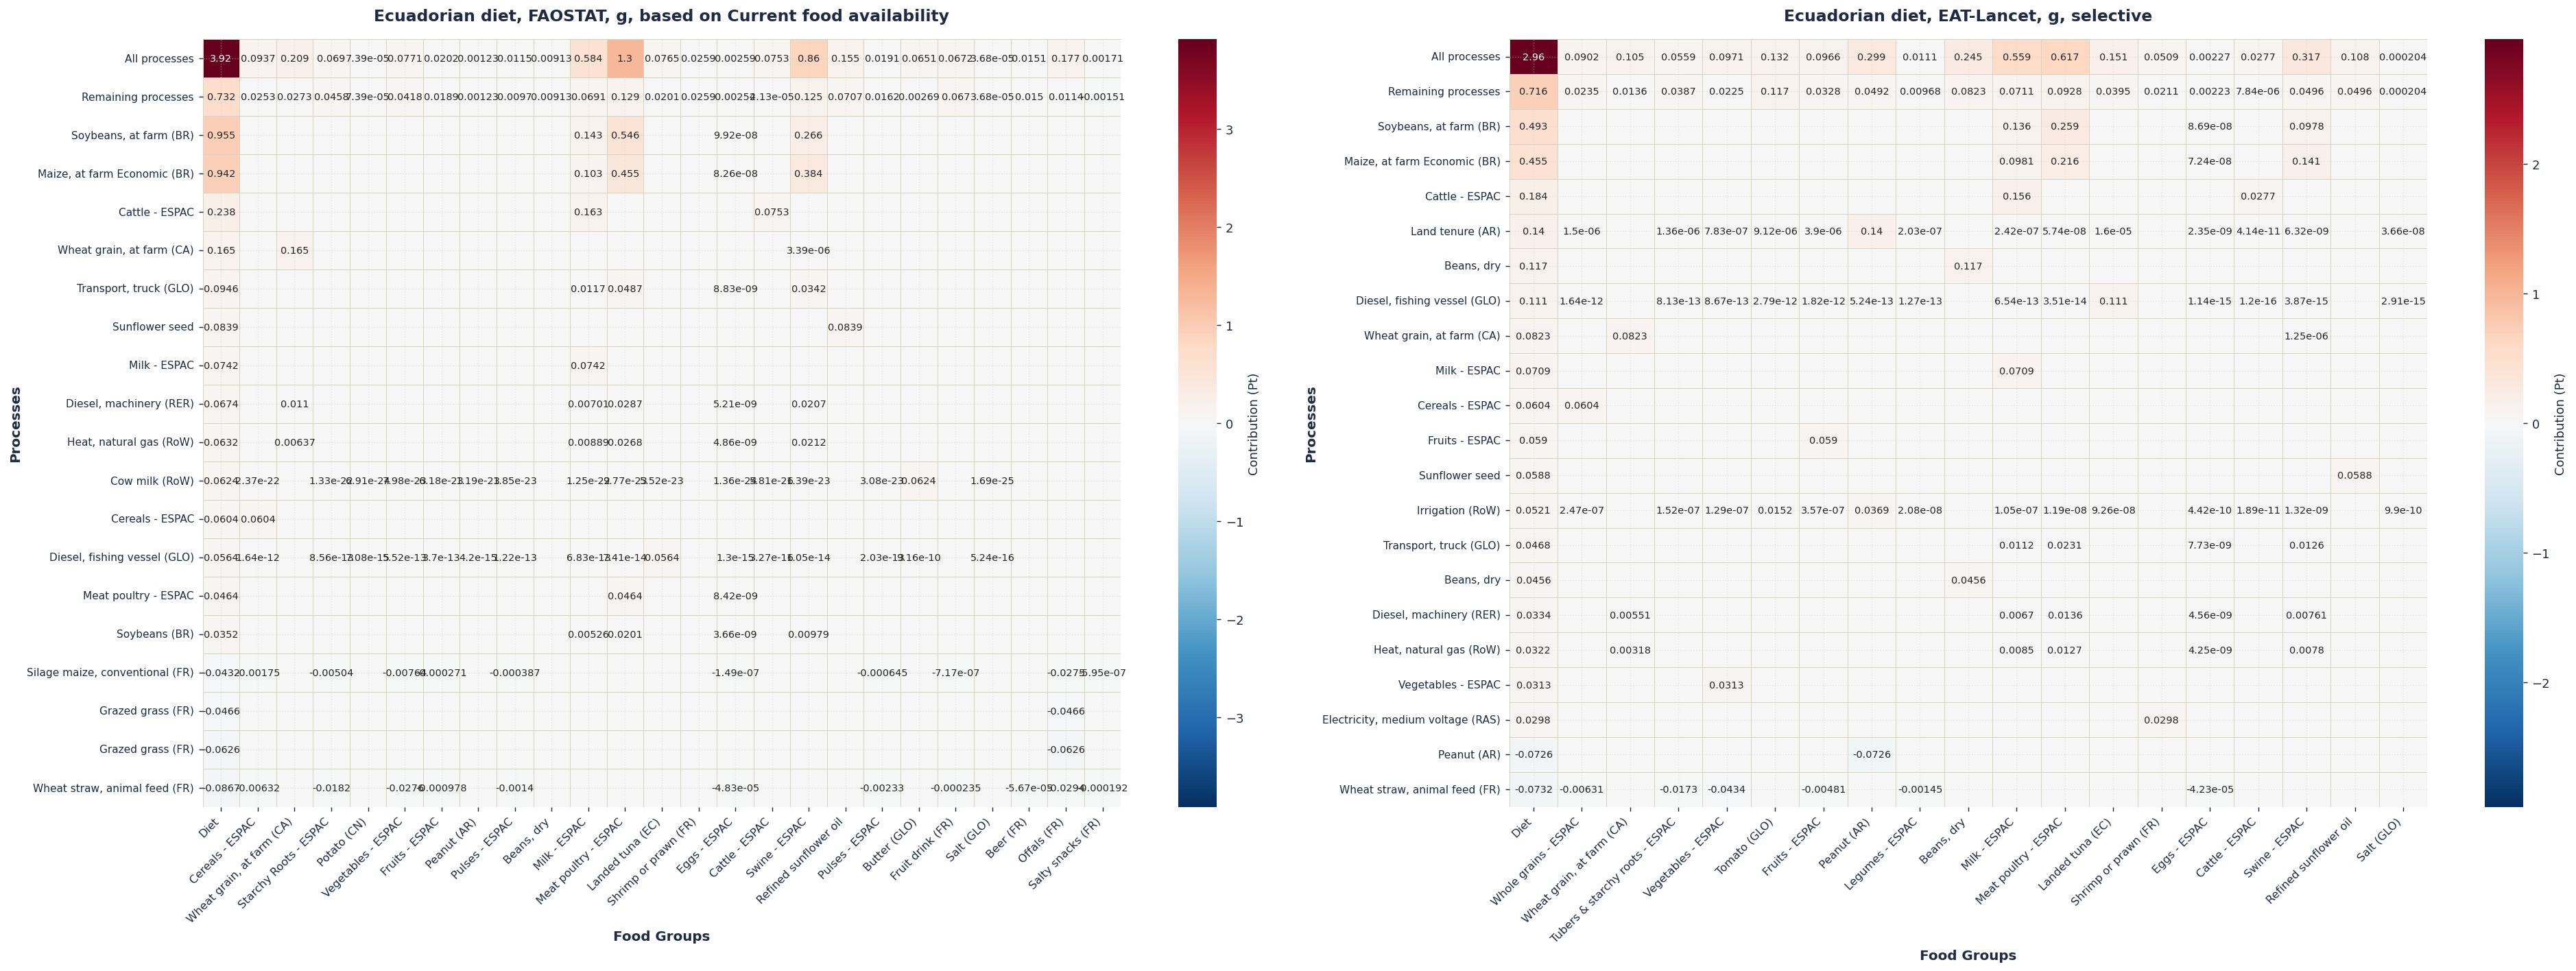

âœ“ Contribution heatmaps saved to: C:\Users\AAVADI\OneDrive - IRTA\Documents\_Proyectos\ESPAC\outputs\reports\figures_lcia_poster\contribution_heatmaps_faostat_eat_lancet.png


In [12]:
# ========== Create Heatmap Visualizations ==========

# Clean diet names for display
diet_names_clean = {
    key: key.replace("1 kg 1. ", "").replace("1 kg 3. ", "").replace(" (del proyecto Ecuador_needs)", "").replace(" (del proyecto Ecuado", "")
    for key in contribution_data_clean.keys()
}

fig, axes = plt.subplots(1, 2, figsize=(30, 11), squeeze=False)
axes = axes.flatten()

for idx, (full_name, clean_name) in enumerate(diet_names_clean.items()):
    if idx >= len(axes):
        break

    ax = axes[idx]
    # Preserve Excel source order â€” no sorting
    data = contribution_data_clean[full_name].copy()
    all_processes_row = pd.DataFrame([data.abs().sum(axis=0).to_numpy()], columns=data.columns, index=['All processes'])
    data = pd.concat([all_processes_row, data], axis=0)

    # Remove columns that are completely empty in the displayed matrix.
    non_empty_cols = data.abs().sum(axis=0) > 0
    data = data.loc[:, non_empty_cols]

    # Symmetric scale around zero to show negatives clearly
    vmax = float(np.nanmax(np.abs(data.values))) if data.size else 1.0
    if vmax == 0:
        vmax = 1.0

    # Blank annotation for values that would render as 0 / -0
    _annot = data.copy().astype(object)
    for _i in range(_annot.shape[0]):
        for _j in range(_annot.shape[1]):
            _v = data.iloc[_i, _j]
            _txt = format(_v, '.3g')
            _annot.iloc[_i, _j] = "" if _txt in {"0", "-0", "0.0", "-0.0", "0.00", "-0.00"} else _txt

    sns.heatmap(
        data,
        annot=_annot,
        fmt='',
        annot_kws={"size": 8},
        cmap='RdBu_r',
        center=0,
        vmin=-vmax,
        vmax=vmax,
        cbar_kws={'label': 'Contribution (Pt)'},
        ax=ax,
        linewidths=0.5,
        linecolor=PALETTE['grid'],
        cbar=True
    )

    ax.set_title(clean_name,
                 fontsize=13, fontweight='bold', color=PALETTE['ink'], pad=15)
    ax.set_xlabel("Food Groups", fontsize=11, fontweight='bold')
    ax.set_ylabel("Processes", fontsize=11, fontweight='bold')
    # Shorten long labels (Land tenure, etc.)
    labels = [shorten_column_name(l.get_text()) for l in ax.get_xticklabels()]
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8.5)

    print(f"{clean_name}: {data.shape[0]} rows x {data.shape[1]} columns")

for idx in range(len(contribution_data_clean), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig(OUT_FIGS / "contribution_heatmaps_faostat_eat_lancet.png", dpi=320, bbox_inches='tight',
            facecolor=PALETTE['bg'], edgecolor='none')
plt.show()

print("âœ“ Contribution heatmaps saved to:", OUT_FIGS / "contribution_heatmaps_faostat_eat_lancet.png")


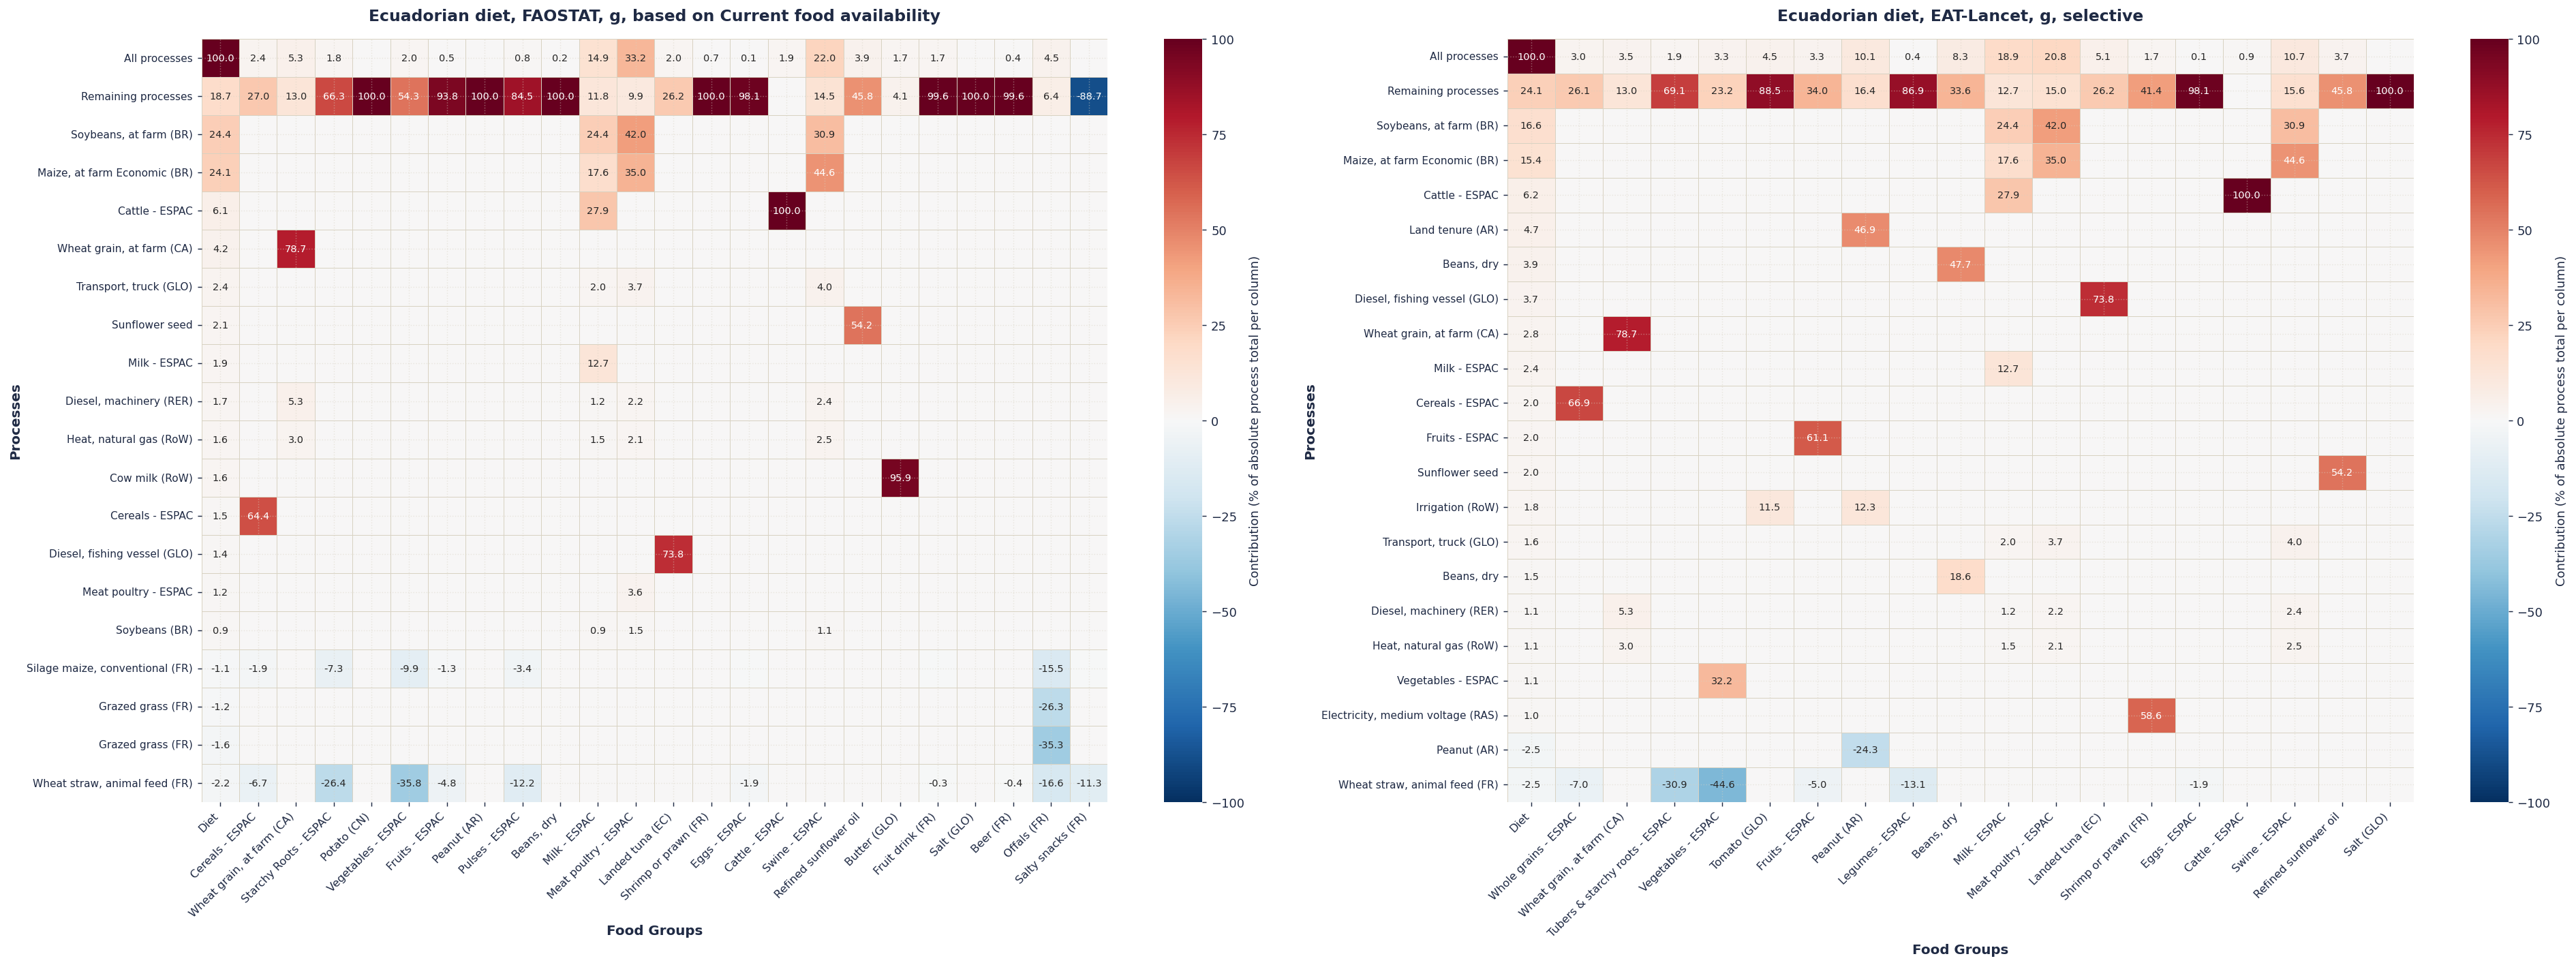

âœ“ Percentage heatmaps saved to: C:\Users\AAVADI\OneDrive - IRTA\Documents\_Proyectos\ESPAC\outputs\reports\figures_lcia_poster\contribution_heatmaps_percentage.png


In [13]:
# ========== Alternative: Percentage Contribution Heatmaps ==========

fig, axes = plt.subplots(1, 2, figsize=(30, 11), squeeze=False)
axes = axes.flatten()

for idx, (full_name, clean_name) in enumerate(diet_names_clean.items()):
    if idx >= len(axes):
        break

    ax = axes[idx]
    is_eat = "EAT-Lancet" in full_name

    # Numerator: displayed process rows (already cleaned, Excel order preserved)
    data = contribution_data_clean[full_name].copy()
    all_processes_row = pd.DataFrame([data.abs().sum(axis=0).to_numpy()], columns=data.columns, index=['All processes'])
    data = pd.concat([all_processes_row, data], axis=0)
    # Preserve original x-axis order from Excel while collapsing duplicate labels.
    data = data.T.groupby(level=0, sort=False).sum().T

    # Build denominator with the exact same x-axis labeling logic.
    raw_df = contribution_data[full_name].copy()
    raw_df = label_raw_columns(raw_df, is_eat_lancet=is_eat)
    raw_df = raw_df.T.groupby(level=0, sort=False).sum().T

    # Denominator for the body rows: use everything except the synthetic first row.
    denom_df = data.iloc[1:].copy()
    col_den = denom_df.abs().sum(axis=0).replace(0, np.nan)

    data_pct = data.div(col_den, axis=1) * 100
    if 'All processes' in data_pct.index and 'Diet' in data.columns:
        diet_total = float(data.loc['All processes', 'Diet']) if pd.notna(data.loc['All processes', 'Diet']) else 0.0
        if diet_total != 0:
            data_pct.loc['All processes'] = data.loc['All processes'] / diet_total * 100
            data_pct.loc['All processes', 'Diet'] = 100.0

    # Dense matrix for full visibility (preserve row order)
    data_display = data_pct.fillna(0.0)

    # Remove columns that are completely empty in the displayed matrix.
    non_empty_cols = data_display.abs().sum(axis=0) > 0
    data_display = data_display.loc[:, non_empty_cols]
    data_pct = data_pct.loc[:, non_empty_cols]
    data = data.loc[:, non_empty_cols]

    vmax = float(np.nanmax(np.abs(data_display.values))) if data_display.size else 1.0
    if vmax == 0:
        vmax = 1.0

    # Blank annotation for values that would render as 0.0 / -0.0
    _annot = data_display.copy().astype(object)
    for _i in range(_annot.shape[0]):
        for _j in range(_annot.shape[1]):
            _v = data_display.iloc[_i, _j]
            _txt = format(_v, '.1f')
            _annot.iloc[_i, _j] = "" if _txt in {"0.0", "-0.0"} else _txt

    sns.heatmap(
        data_display,
        annot=_annot,
        fmt='',
        annot_kws={"size": 8},
        cmap='RdBu_r',
        center=0,
        vmin=-vmax,
        vmax=vmax,
        cbar_kws={'label': 'Contribution (% of absolute process total per column)'},
        ax=ax,
        linewidths=0.5,
        linecolor=PALETTE['grid'],
        cbar=True
    )

    ax.set_title(clean_name,
                 fontsize=13, fontweight='bold', color=PALETTE['ink'], pad=15)
    ax.set_xlabel("Food Groups", fontsize=11, fontweight='bold')
    ax.set_ylabel("Processes", fontsize=11, fontweight='bold')
    # Shorten long labels (Land tenure, etc.)
    labels = [shorten_column_name(l.get_text()) for l in ax.get_xticklabels()]
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8.5)



for idx in range(len(contribution_data_clean), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig(OUT_FIGS / "contribution_heatmaps_percentage.png", dpi=320, bbox_inches='tight',
            facecolor=PALETTE['bg'], edgecolor='none')
plt.show()

print("âœ“ Percentage heatmaps saved to:", OUT_FIGS / "contribution_heatmaps_percentage.png")


In [14]:
# ========== Contribution Summary Statistics ==========

summary_stats = []

for full_name, clean_name in diet_names_clean.items():
    data = contribution_data_clean[full_name]
    
    # Calculate statistics
    total_impact = data.sum().sum()
    n_processes = len(data)
    n_food_groups = len(data.columns)
    
    # Find dominant food group (highest total contribution)
    food_group_totals = data.sum(axis=0)
    dominant_group = food_group_totals.idxmax()
    dominant_pct = (food_group_totals.max() / total_impact) * 100
    
    # Find dominant process (highest total contribution)
    process_totals = data.sum(axis=1)
    dominant_process = process_totals.idxmax()
    dominant_process_pct = (process_totals.max() / total_impact) * 100
    
    # Get top 3 food groups
    top_3_groups = food_group_totals.nlargest(3)
    top_3_pct = (top_3_groups.sum() / total_impact) * 100
    
    summary_stats.append({
        'Diet': clean_name[:50],
        'Total Impact (Pt)': f"{total_impact:.2f}",
        'Processes': n_processes,
        'Food Groups': n_food_groups,
        'Top Food Group': dominant_group,
        'Top Group %': f"{dominant_pct:.1f}%",
        'Top 3 Groups %': f"{top_3_pct:.1f}%",
        'Top Process': dominant_process[:40],
        'Top Process %': f"{dominant_process_pct:.1f}%"
    })

summary_df = pd.DataFrame(summary_stats)
display(Markdown("### Contribution Analyses Summary"))
display(summary_df)

# Save summary as CSV
summary_df.to_csv(OUT_REPORTS / "contribution_analyses_summary_faostat_eat_lancet.csv", index=False)
print("\nâœ“ Summary saved to:", OUT_REPORTS / "contribution_analyses_summary_faostat_eat_lancet.csv")


### Contribution Analyses Summary

,Diet,Total Impact (Pt),Processes,Food Groups,Top Food Group,Top Group %,Top 3 Groups %,Top Process,Top Process %
0,"Ecuadorian diet, FAOSTAT, g, based on Current ...",6.87,19,26,Diet,50.0%,81.5%,"Soybeans, at farm (BR)",27.8%
1,"Ecuadorian diet, EAT-Lancet, g, selective",5.35,21,20,Diet,50.0%,72.0%,Remaining processes,26.8%



âœ“ Summary saved to: C:\Users\AAVADI\OneDrive - IRTA\Documents\_Proyectos\ESPAC\outputs\reports\contribution_analyses_summary_faostat_eat_lancet.csv


In [19]:
# ========== Sankey diagrams for annual national diet demand (2022) ==========

from pathlib import Path
import re

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from IPython.display import Markdown, display

YEAR = 2022
DIETS_SHEET = "diets"
EXCESS_FOOD_LABEL = "Excess food"

if "ROOT" not in globals():
    ROOT = Path.cwd()
    if not (ROOT / "outputs" / "ESPAC LCIA.xlsx").exists():
        ROOT = ROOT.parent

if "WB_PATH" not in globals():
    WB_PATH = ROOT / "outputs" / "ESPAC LCIA.xlsx"

if "OUT_FIGS" not in globals():
    OUT_FIGS = ROOT / "outputs" / "reports" / "figures_lcia_poster"
    OUT_FIGS.mkdir(parents=True, exist_ok=True)

if "PALETTE" not in globals():
    PALETTE = {
        "bg": "#f7f4ea",
        "ink": "#1f2a44",
    }

PLOTLY_CONFIG = {
    "displaylogo": False,
    "modeBarButtonsToAdd": ["toImage"],
    "toImageButtonOptions": {"format": "png", "filename": "espac_sankey", "scale": 2},
}


df_diets_raw = pd.read_excel(WB_PATH, sheet_name=DIETS_SHEET, header=None)

# Dynamic row detection
def detect_food_group_row_ids(df_raw: pd.DataFrame, group_col: int, header_scan_start: int = 0) -> list[int]:
    row_ids = []
    started = False
    for i in range(header_scan_start, len(df_raw)):
        val = df_raw.iloc[i, group_col] if group_col < df_raw.shape[1] else None
        txt = str(val).strip() if pd.notna(val) else ""
        if not started:
            if txt and txt.lower() != 'nan':
                started = True
            else:
                continue
        if txt == "" or txt.lower() == 'nan':
            if row_ids:
                break
            continue
        if txt.lower() == 'total':
            break
        row_ids.append(i)
    return row_ids

# Column mapping (Excel letters -> 0-based indices)
COL_A_MEAT_DETAIL = 0
COL_B_GROUP = 1
COL_C_CURRENT_DIET = 2
COL_D_NATIONAL = 3
COL_E_NATIONAL_INCL_EXPORTS = 4
COL_F_IMPORTS = 5
COL_H_ADDITIONAL_DOMESTIC = 7

# EAT-Lancet columns requested by user
EAT_GROUP_COL = 9   # J
COL_J_EAT_DIET = 11  # L in workbook view
COL_O_ADDITIONAL_FOOD = 14  # O
COL_P_NATIONAL = 15         # P
COL_Q_NATIONAL = 16         # Q
COL_R_IMPORTS = 17          # R
COL_T_ADDITIONAL_DOMESTIC = 19  # T


def compose_food_group_label(group_value: object, detail_value: object) -> str:
    group_txt = str(group_value).strip() if pd.notna(group_value) else ""
    detail_txt = str(detail_value).strip() if pd.notna(detail_value) else ""
    if group_txt and detail_txt and detail_txt.lower() not in {group_txt.lower(), "nan"}:
        return f"{group_txt} - {detail_txt}"
    return group_txt


def wrap_title_text(title_text: str, width: int = 62) -> str:
    words = str(title_text).split()
    if len(words) <= 1:
        return str(title_text)

    best_split = 1
    best_score = float("inf")
    for i in range(1, len(words)):
        left = " ".join(words[:i])
        right = " ".join(words[i:])
        score = abs(len(left) - len(right))
        if score < best_score:
            best_score = score
            best_split = i

    left = " ".join(words[:best_split])
    right = " ".join(words[best_split:])
    return f"{left}<br>{right}"


def build_multi_source_balance(
    df_raw: pd.DataFrame,
    row_ids: list[int],
    group_col: int,
    detail_col: int | None,
    demand_col: int,
    source_specs: list[dict],
) -> pd.DataFrame:
    food_group_series = df_raw.iloc[row_ids, group_col]
    if detail_col is None:
        labels = food_group_series.astype(str).str.strip()
    else:
        detail_series = df_raw.iloc[row_ids, detail_col]
        labels = [compose_food_group_label(g, d) for g, d in zip(food_group_series, detail_series)]

    out = pd.DataFrame({
        "food_group": labels,
        "demand_t_per_year": pd.to_numeric(df_raw.iloc[row_ids, demand_col], errors="coerce"),
    }).copy()

    for src in source_specs:
        out[src["col_name"]] = pd.to_numeric(df_raw.iloc[row_ids, src["col_idx"]], errors="coerce")

    out["food_group"] = out["food_group"].astype(str).str.strip()
    out = out[out["food_group"].ne("")].copy()
    out["demand_t_per_year"] = out["demand_t_per_year"].fillna(0.0).clip(lower=0.0)

    source_cols = [src["col_name"] for src in source_specs]
    for c in source_cols:
        out[c] = out[c].fillna(0.0).clip(lower=0.0)

    row_supply = out[source_cols].sum(axis=1)
    # Satisfy diet demand first; only surplus goes to Excess food.
    out["current_diet_flow_t_per_year"] = np.minimum(out["demand_t_per_year"], row_supply)
    out["excess_food_t_per_year"] = np.maximum(row_supply - out["demand_t_per_year"], 0.0)

    return out.reset_index(drop=True)


def plot_multi_source_sankey(
    balance_df: pd.DataFrame,
    diet_label: str,
    year: int,
    source_specs: list[dict],
) -> go.Figure:
    current_flow_total = float(balance_df["current_diet_flow_t_per_year"].sum())
    excess_total = float(balance_df["excess_food_t_per_year"].sum())

    source_labels = []
    for src in source_specs:
        src_total = float(balance_df[src["col_name"]].sum())
        source_labels.append(f"{src['label']} ({src_total / 1e6:.2f} Mt/y)")

    node_labels = [
        *source_labels,
        *balance_df["food_group"].tolist(),
        f"{diet_label} total ({current_flow_total / 1e6:.2f} Mt/y)",
    ]

    has_excess = excess_total > 0
    if has_excess:
        node_labels.append(f"{EXCESS_FOOD_LABEL} total ({excess_total / 1e6:.2f} Mt/y)")

    source_count = len(source_specs)
    group_offset = source_count
    current_sink_idx = group_offset + len(balance_df)
    excess_sink_idx = current_sink_idx + 1 if has_excess else None

    source = []
    target = []
    value = []
    link_color = []

    for ridx, row in balance_df.iterrows():
        group_idx = group_offset + ridx

        for sidx, src in enumerate(source_specs):
            src_val = float(row[src["col_name"]])
            if src_val > 0:
                source.append(sidx)
                target.append(group_idx)
                value.append(src_val)
                link_color.append(src["link_color"])

        current_val = float(row["current_diet_flow_t_per_year"])
        excess_val = float(row["excess_food_t_per_year"])

        if current_val > 0:
            source.append(group_idx)
            target.append(current_sink_idx)
            value.append(current_val)
            link_color.append("rgba(76, 120, 168, 0.40)")

        if has_excess and excess_val > 0:
            source.append(group_idx)
            target.append(excess_sink_idx)
            value.append(excess_val)
            link_color.append("rgba(196, 78, 82, 0.45)")

    node_colors = [src["node_color"] for src in source_specs]
    node_colors += ["rgba(76, 120, 168, 0.85)" for _ in range(len(balance_df))]
    node_colors.append("rgba(31, 42, 68, 0.95)")
    if has_excess:
        node_colors.append("rgba(196, 78, 82, 0.95)")

    source_labels_for_title = [src["label"].lower() for src in source_specs]
    if len(source_labels_for_title) == 1:
        source_phrase = source_labels_for_title[0]
    elif len(source_labels_for_title) == 2:
        source_phrase = f"{source_labels_for_title[0]} and {source_labels_for_title[1]}"
    else:
        source_phrase = ", ".join(source_labels_for_title[:-1]) + f", and {source_labels_for_title[-1]}"

    fig = go.Figure(
        data=[
            go.Sankey(
                arrangement="snap",
                node=dict(
                    label=node_labels,
                    pad=18,
                    thickness=18,
                    color=node_colors,
                    line=dict(color="rgba(31, 42, 68, 0.35)", width=0.5),
                ),
                link=dict(
                    source=source,
                    target=target,
                    value=value,
                    color=link_color,
                    hovertemplate="%{source.label} -> %{target.label}<br>%{value:,.0f} t/y<extra></extra>",
                ),
            )
        ]
    )

    title_text = f"{diet_label}: annual consumption split between {source_phrase} ({year})"

    fig.update_layout(
        title=dict(text=wrap_title_text(title_text), x=0.5, xanchor="center"),
        font=dict(size=12, color=PALETTE["ink"]),
        paper_bgcolor="rgba(0,0,0,0)",
        plot_bgcolor="rgba(0,0,0,0)",
        margin=dict(l=20, r=20, t=60, b=20),
        height=max(640, 24 * len(balance_df) + 240),
    )
    return fig


# Source definitions reused across sankeys
SRC_NATIONAL_AVAILABLE = {
    "label": "National production available as food",
    "node_color": "rgba(42, 157, 143, 0.95)",
    "link_color": "rgba(42, 157, 143, 0.70)",
}
SRC_FOOD_IMPORTS = {
    "label": "Food Imports",
    "node_color": "rgba(217, 111, 50, 0.95)",
    "link_color": "rgba(217, 111, 50, 0.75)",
}
SRC_ADDITIONAL_DOMESTIC = {
    "label": "Additional domestic production required",
    "node_color": "rgba(114, 147, 203, 0.95)",
    "link_color": "rgba(114, 147, 203, 0.70)",
}
SRC_ADDITIONAL_FOOD = {
    "label": "Additional food rquired (imports or domestic production)",
    "node_color": "rgba(162, 95, 175, 0.95)",
    "link_color": "rgba(162, 95, 175, 0.70)",
}


CURRENT_ROW_IDS = detect_food_group_row_ids(df_diets_raw, group_col=1, header_scan_start=3)
EAT_ROW_IDS = detect_food_group_row_ids(df_diets_raw, group_col=9, header_scan_start=3)

print(f"Detected FAOSTAT diet rows: Excel {CURRENT_ROW_IDS[0]+1}..{CURRENT_ROW_IDS[-1]+1}")
print(f"Detected EAT-Lancet diet rows: Excel {EAT_ROW_IDS[0]+1}..{EAT_ROW_IDS[-1]+1}")

sankey_specs = [
    {
        "section_title": "1. Current Ecuadorian diet (FAOSTAT)",
        "diet_label": "1. Current Ecuadorian diet (FAOSTAT)",
        "file_stub": "current_ecuadorian_diet_faostat",
        "row_ids": CURRENT_ROW_IDS,
        "group_col": COL_B_GROUP,
        "detail_col": COL_A_MEAT_DETAIL,
        "demand_col": COL_C_CURRENT_DIET,
        "source_specs": [
            {"col_idx": COL_D_NATIONAL, "col_name": "national_production_t_per_year", **SRC_NATIONAL_AVAILABLE},
            {"col_idx": COL_F_IMPORTS, "col_name": "imports_t_per_year", **SRC_FOOD_IMPORTS},
        ],
    },
    {
        "section_title": "2. EAT-Lancet diet (selective)",
        "diet_label": "2. EAT-Lancet diet (selective)",
        "file_stub": "eat_lancet_diet_selective",
        "row_ids": EAT_ROW_IDS,
        "group_col": EAT_GROUP_COL,
        "detail_col": None,
        "demand_col": COL_J_EAT_DIET,
        "source_specs": [
            {"col_idx": COL_P_NATIONAL, "col_name": "national_production_available_t_per_year", **SRC_NATIONAL_AVAILABLE},
            {"col_idx": COL_R_IMPORTS, "col_name": "food_imports_t_per_year", **SRC_FOOD_IMPORTS},
            {"col_idx": COL_O_ADDITIONAL_FOOD, "col_name": "additional_food_t_per_year", **SRC_ADDITIONAL_FOOD},
        ],
    },
    {
        "section_title": "3. Current Ecuadorian diet (FAOSTAT) - self-sufficient",
        "diet_label": "3. Current Ecuadorian diet (FAOSTAT) - self-sufficient",
        "file_stub": "current_ecuadorian_diet_faostat_self_sufficient",
        "row_ids": CURRENT_ROW_IDS,
        "group_col": COL_B_GROUP,
        "detail_col": COL_A_MEAT_DETAIL,
        "demand_col": COL_C_CURRENT_DIET,
        "source_specs": [
            {"col_idx": COL_E_NATIONAL_INCL_EXPORTS, "col_name": "national_production_including_exports_t_per_year", **SRC_NATIONAL_AVAILABLE},
            {"col_idx": COL_H_ADDITIONAL_DOMESTIC, "col_name": "additional_domestic_production_t_per_year", **SRC_ADDITIONAL_DOMESTIC},
        ],
    },
    {
        "section_title": "4. EAT-Lancet diet (selective) - self-sufficient",
        "diet_label": "4. EAT-Lancet diet (selective) - self-sufficient",
        "file_stub": "eat_lancet_diet_selective_self_sufficient",
        "row_ids": EAT_ROW_IDS,
        "group_col": EAT_GROUP_COL,
        "detail_col": None,
        "demand_col": COL_J_EAT_DIET,
        "source_specs": [
            {"col_idx": COL_Q_NATIONAL, "col_name": "national_production_available_t_per_year", **SRC_NATIONAL_AVAILABLE},
            {"col_idx": COL_T_ADDITIONAL_DOMESTIC, "col_name": "additional_domestic_production_t_per_year", **SRC_ADDITIONAL_DOMESTIC},
        ],
    },
]


for spec in sankey_specs:
    balance_df = build_multi_source_balance(
        df_raw=df_diets_raw,
        row_ids=spec["row_ids"],
        group_col=spec["group_col"],
        detail_col=spec["detail_col"],
        demand_col=spec["demand_col"],
        source_specs=spec["source_specs"],
    )

    display(Markdown(f"### {spec['section_title']}"))

    display_cols = ["food_group", *[s["col_name"] for s in spec["source_specs"]], "current_diet_flow_t_per_year"]
    display_names = {
        "food_group": "Food group",
        "current_diet_flow_t_per_year": "Flow to diet (t/y)",
    }
    for s in spec["source_specs"]:
        display_names[s["col_name"]] = f"{s['label']} (t/y)"

    if balance_df["excess_food_t_per_year"].sum() > 0:
        display_cols.append("excess_food_t_per_year")
        display_names["excess_food_t_per_year"] = "Excess food (t/y)"

    display_df = balance_df[display_cols].rename(columns=display_names)
    style_map = {c: "{:,.0f}" for c in display_df.columns if c != "Food group"}
    display(display_df.style.format(style_map))

    fig = plot_multi_source_sankey(
        balance_df=balance_df,
        diet_label=spec["diet_label"],
        year=YEAR,
        source_specs=spec["source_specs"],
    )
    fig.show(config=PLOTLY_CONFIG)

    html_path = OUT_FIGS / f"sankey_{spec['file_stub']}_{YEAR}.html"
    fig.write_html(html_path, include_plotlyjs="cdn", config=PLOTLY_CONFIG)
    print("Saved:", html_path)

Detected FAOSTAT diet rows: Excel 4..23
Detected EAT-Lancet diet rows: Excel 4..20


### 1. Current Ecuadorian diet (FAOSTAT)

,Food group,National production available as food (t/y),Food Imports (t/y),Flow to diet (t/y),Excess food (t/y)
0,Cereals - Excluding Beer,"492,000","2,056,000","2,033,179","514,821"
1,Starchy Roots,"306,900","59,000","358,792","7,108"
2,Vegetables,"264,000","70,000","249,024","84,976"
3,Fruits - Excluding Wine,"189,000","138,000","264,132","62,868"
4,Treenuts,0,"6,000","2,852","3,148"
5,Pulses,"6,000","27,000","33,000",0
6,Milk - Excluding Butter,"2,016,000","21,000","1,697,277","339,723"
7,Meat - poultry,"464,026","6,000","411,334","58,691"
8,"Fish, Seafood","494,495","236,760","98,716","632,539"
9,Eggs,"112,000","1,000","111,221","1,779"


Saved: c:\Users\AAVADI\OneDrive - IRTA\Documents\_Proyectos\ESPAC\outputs\reports\figures_lcia_poster\sankey_current_ecuadorian_diet_faostat_2022.html


### 2. EAT-Lancet diet (selective)

...

,Food group,National production available as food (t/y),Additional domestic production required (t/y),Flow to diet (t/y),Excess food (t/y)
0,Cereals - Excluding Beer,"580,000","1,453,179","2,033,179",0
1,Starchy Roots,"342,000","16,792","358,792",0
2,Vegetables,"392,000",0,"249,024","142,976"
3,Fruits - Excluding Wine,"5,531,400",0,"264,132","5,267,268"
4,Treenuts,0,"2,852","2,852",0
5,Pulses,"16,000","17,366","33,366",0
6,Milk - Excluding Butter,"2,021,000",0,"1,697,277","323,723"
7,Meat - poultry,"464,026",0,"411,334","52,691"
8,"Fish, Seafood","1,923,655",0,"98,716","1,824,939"
9,Eggs,"112,000",0,"111,221",779


Saved: c:\Users\AAVADI\OneDrive - IRTA\Documents\_Proyectos\ESPAC\outputs\reports\figures_lcia_poster\sankey_current_ecuadorian_diet_faostat_self_sufficient_2022.html


### 4. EAT-Lancet diet (selective) - self-sufficient

,Food group,National production available as food (t/y),Additional domestic production required (t/y),Flow to diet (t/y),Excess food (t/y)
0,Whole grains,"580,000","727,650","1,307,650",0
1,Tubers and starchy roots,"342,000",0,"325,286","16,714"
2,Vegetables,"392,000","1,559,717","1,951,717",0
3,Fruits,"5,531,400",0,"1,301,144","4,230,256"
4,Tree nuts and peanuts,0,"325,286","325,286",0
5,Legumes,"16,000","471,929","487,929",0
6,Milk or equivalents,"2,021,000",0,"1,626,431","394,569"
7,Poultry,"464,026",0,"195,172","268,854"
8,Fish,"1,923,655",0,"195,172","1,728,483"
9,Eggs,"112,000",0,"97,586","14,414"


Saved: c:\Users\AAVADI\OneDrive - IRTA\Documents\_Proyectos\ESPAC\outputs\reports\figures_lcia_poster\sankey_eat_lancet_diet_selective_self_sufficient_2022.html


In [16]:
# debug check: EAT-Lancet row-window totals around demand columns (rows 4..20)
_tmp = pd.read_excel(WB_PATH, sheet_name=DIETS_SHEET, header=None)
_rows = list(range(3, 20))
for _idx in range(8, 13):
    _s = pd.to_numeric(_tmp.iloc[_rows, _idx], errors="coerce")
    print("col", _idx, "sum=", float(_s.fillna(0).sum()), "non_null=", int(_s.notna().sum()))

col 8 sum= 0.0 non_null= 0
col 9 sum= 0.0 non_null= 0
col 10 sum= 7779070.202338053 non_null= 17
col 11 sum= 8203715.9527050005 non_null= 17
col 12 sum= 7366825.704411809 non_null= 17
